# CLIP best wf score model Modified

- Added BERT for text data
- Added CLIP to handle image data
- Added XAI

accuracy: 0.6923  
val_accuracy: 0.6229    
Precision: 0.5498  
Recall: 0.6343  
F1-Score: 0.5448  
Weighted F1-Score: 0.6552    

In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
from transformers import CLIPProcessor, TFCLIPModel, TFBertModel, BertTokenizer
from tensorflow.keras.layers import Dense, Input, Dropout, LayerNormalization, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from PIL import Image
import os
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, precision_recall_curve, auc, accuracy_score, mean_absolute_error
from sklearn.utils.class_weight import compute_class_weight
import shap
import matplotlib.pyplot as plt
import seaborn as sns

def load_data(train_path, test_path):
    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)
    return train_df, test_df

def get_image_paths(directory, image_names):
    return [os.path.join(directory, img) for img in image_names]

class MultimodalSentimentModel:
    def __init__(self, num_classes=3):
        self.num_classes = num_classes
        self.processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
        self.clip = TFCLIPModel.from_pretrained("openai/clip-vit-base-patch32")
        self.tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
        self.bert = TFBertModel.from_pretrained("bert-base-uncased")
        
        self.clip.trainable = False
        self.bert.trainable = False
    
    def process_batch(self, images, texts):
        # Preprocess images and texts
        clip_inputs = self.processor(
            images=images, text=texts, return_tensors="tf", padding=True, truncation=True
        )
        bert_inputs = self.tokenizer(
            texts, return_tensors="tf", padding=True, truncation=True
        )
        return {
            "input_ids": bert_inputs["input_ids"],
            "attention_mask": bert_inputs["attention_mask"],
            "pixel_values": clip_inputs["pixel_values"]
        }
    
    def build_model(self):
        # Define input layers
        input_ids = Input(shape=(None,), dtype=tf.int32, name="input_ids")
        attention_mask = Input(shape=(None,), dtype=tf.int32, name="attention_mask")
        pixel_values = Input(shape=(3, 224, 224), dtype=tf.float32, name="pixel_values")
        
        # Process text with BERT
        text_outputs = self.bert(input_ids, attention_mask=attention_mask).last_hidden_state[:, 0, :]
        
        # Process images with CLIP (correct integration)
        clip_outputs = self.clip(pixel_values)  # Pass pixel_values as a positional argument
        image_outputs = clip_outputs.pooler_output  # Use pooled image features
        
        # Combine features
        combined = Concatenate()([text_outputs, image_outputs])
        x = Dense(512, activation="relu")(combined)
        x = Dropout(0.3)(x)
        x = LayerNormalization()(x)
        x = Dense(256, activation="relu")(x)
        x = Dropout(0.2)(x)
        outputs = Dense(self.num_classes, activation="softmax")(x)
        
        # Compile model
        model = Model(
            inputs=[input_ids, attention_mask, pixel_values], 
            outputs=outputs
        )
        model.compile(
            optimizer=Adam(learning_rate=2e-5),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"]
        )
        return model

def train_model(train_data, val_data, epochs=20):
    model_handler = MultimodalSentimentModel()
    model = model_handler.build_model()
    
    # Preprocess data
    train_inputs = model_handler.process_batch(train_data[0][0], train_data[0][1])
    val_inputs = model_handler.process_batch(val_data[0][0], val_data[0][1])
    
    # Extract labels
    train_labels = train_data[1]
    val_labels = val_data[1]
    
    # Define callbacks
    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=2, min_lr=1e-6)
    ]
    
    # Train the model
    history = model.fit(
        x=[train_inputs["input_ids"], train_inputs["attention_mask"], train_inputs["pixel_values"]],
        y=train_labels,
        validation_data=(
            [val_inputs["input_ids"], val_inputs["attention_mask"], val_inputs["pixel_values"]],
            val_labels
        ),
        epochs=epochs,
        batch_size=32,
        callbacks=callbacks
    )
    return model, history

# Rest of the code (evaluate_model, main, etc.) remains unchanged

def evaluate_model(model, test_inputs, test_labels, label_map):
    predictions = model.predict(test_inputs)
    predicted_labels = np.argmax(predictions, axis=1)
    
    accuracy = accuracy_score(test_labels, predicted_labels)
    precision = precision_score(test_labels, predicted_labels, average='weighted')
    recall = recall_score(test_labels, predicted_labels, average='weighted')
    f1_weighted = f1_score(test_labels, predicted_labels, average='weighted')
    conf_matrix = confusion_matrix(test_labels, predicted_labels)
    roc_auc = roc_auc_score(test_labels, predictions, multi_class='ovr')
    pr_auc = auc(*precision_recall_curve(test_labels, predictions[:, 1])[:2])
    mae = mean_absolute_error(test_labels, predicted_labels)
    
    print(f'Accuracy: {accuracy:.4f}')
    print(f'Precision (Weighted): {precision:.4f}')
    print(f'Recall (Weighted): {recall:.4f}')
    print(f'F1 Score (Weighted): {f1_weighted:.4f}')
    print(f'ROC AUC Score: {roc_auc:.4f}')
    print(f'Precision-Recall AUC: {pr_auc:.4f}')
    print(f'MAE: {mae:.4f}')
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=label_map.keys(), yticklabels=label_map.keys())
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()
    
    precision_vals, recall_vals, _ = precision_recall_curve(test_labels, predictions[:, 1])
    plt.figure(figsize=(8, 6))
    plt.plot(recall_vals, precision_vals, marker='.')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.show()

def main():
    dataset_path = '/kaggle/input/memosen-with-label/multi-sent.csv'
    memes_folder = '/kaggle/input/multimodal-sentiment-analysis-cuet-nlp/Memes/Memes'
    
    # Load dataset with encoding handling
    try:
        combined_df = pd.read_csv(dataset_path, encoding='utf-8')
    except UnicodeDecodeError:
        try:
            combined_df = pd.read_csv(dataset_path, encoding='latin-1')
        except Exception as e:
            print(f"Failed to read the CSV file: {e}")
            return
    
    print("Combined DataFrame Columns:", combined_df.columns)
    
    if 'Label_Sentiment' not in combined_df.columns:
        raise KeyError("Column 'Label_Sentiment' not found in the dataset.")
    
    # Handle missing values and invalid labels
    print("Missing values in 'Label_Sentiment':", combined_df['Label_Sentiment'].isna().sum())
    print("Unique values in 'Label_Sentiment':", combined_df['Label_Sentiment'].unique())
    
    valid_labels = ['positive', 'neutral', 'negative']
    combined_df = combined_df[combined_df['Label_Sentiment'].isin(valid_labels)]
    
    if combined_df.empty:
        raise ValueError("The dataset is empty after cleaning invalid labels.")
    
    label_map = {'positive': 2, 'neutral': 1, 'negative': 0}
    combined_df['Label_Sentiment'] = combined_df['Label_Sentiment'].map(label_map)
    
    # Split dataset into train and test sets (80-20 ratio)
    train_df, test_df = train_test_split(
        combined_df, test_size=0.2, random_state=42, stratify=combined_df['Label_Sentiment']
    )
    
    test_labels_df = test_df[['Label_Sentiment']].copy()
    test_df = test_df.drop(columns=['Label_Sentiment'])
    
    train_image_paths = get_image_paths(memes_folder, train_df['image_name'].tolist())
    test_image_paths = get_image_paths(memes_folder, test_df['image_name'].tolist())
    
    train_labels = train_df['Label_Sentiment'].values
    test_labels = test_labels_df['Label_Sentiment'].values
    
    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(train_labels),
        y=train_labels
    )
    class_weights = dict(enumerate(class_weights))
    
    # Prepare inputs for training
    train_inputs = (train_image_paths, train_df['Captions'].tolist())
    val_inputs = (test_image_paths, test_df['Captions'].tolist())

    train_data = (train_inputs, train_labels)
    val_data = (val_inputs, test_labels)

    # Train model
    model, history = train_model(train_data, val_data, epochs=20)

    print("Processing test data...")
    model_handler = MultimodalSentimentModel()
    test_inputs = model_handler.process_batch(test_image_paths, test_df['Captions'].tolist())

    # Evaluate model
    evaluate_model(model, test_inputs, test_labels, label_map)
    
    predictions = model.predict(test_inputs)
    predicted_labels = np.argmax(predictions, axis=1)
    
    reverse_label_map = {v: k for k, v in label_map.items()}
    test_df['Label'] = [reverse_label_map[label] for label in predicted_labels]
    
    if 'Id' not in test_df.columns:
        test_df['Id'] = range(1, len(test_df) + 1)
        print("Warning: 'Id' column not found. A unique identifier has been created.")
    
    test_df[['Id', 'Label']].to_csv('submission.csv', index=False)
    print("Predictions saved to submission.csv")
    
    return model, history

if __name__ == "__main__":
    main()

# CLIP best wf score model Modified

- Added BERT for text data
- Added CLIP to handle image data
- Added XAI

epoch: 20
accuracy: 0.7079  
val_accuracy: 0.7143  
Precision: 0.4593  
Recall: 0.4517  
F1-Score: 0.4454  
Weighted F1-Score: 0.6632  

In [4]:
!pip install --upgrade transformers

/bin/bash: /opt/conda/lib/libtinfo.so.6: no version information available (required by /bin/bash)
  Using cached transformers-4.30.2-py3-none-any.whl (7.2 MB)
  Using cached safetensors-0.5.3.tar.gz (67 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... error
  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [6 lines of output]
      
      Cargo, the Rust package manager, is not installed or is not on PATH.
      This package requires Rust and Cargo to compile extensions. Install it through
      the system's package manager or via https://rustup.rs/
      
      Checking for Rust toolchain....
      [end of output]
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note:

In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
from transformers import CLIPProcessor, TFCLIPModel, TFBertModel, BertTokenizer
from tensorflow.keras.layers import Dense, Input, Dropout, LayerNormalization, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from PIL import Image
import os
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, precision_recall_curve, auc, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

def load_data(train_path, test_path):
    """Load training and test data"""
    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)
    return train_df, test_df

def get_image_paths(directory, image_names):
    """Get full paths for images"""
    image_paths = {img: os.path.join(directory, img) for img in image_names}
    return [image_paths[img] for img in image_names if img in image_paths]

class MultimodalSentimentModel:
    def __init__(self, num_classes=3):
        self.num_classes = num_classes
        
        # Image model (CLIP)
        self.clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
        self.clip_model = TFCLIPModel.from_pretrained("openai/clip-vit-base-patch32")
        self.clip_model.trainable = False  # Freeze CLIP layers
        
        # Text model (BERT)
        self.bert_tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
        self.bert_model = TFBertModel.from_pretrained("bert-base-uncased")
        self.bert_model.trainable = False  # Freeze BERT layers
        
        # Set max lengths
        self.max_text_length = 128
    
    def process_text_batch(self, texts):
        """Process a batch of texts through BERT tokenizer"""
        inputs = self.bert_tokenizer(
            texts,
            return_tensors="tf",
            padding='max_length',
            truncation=True,
            max_length=self.max_text_length
        )
        return inputs
    
    def process_image_batch(self, images):
        """Process a batch of images through CLIP image processor"""
        inputs = self.clip_processor(
            images=images,
            return_tensors="tf",
            padding='max_length',
            truncation=True,
        )
        return {'pixel_values': inputs['pixel_values']}
    
    def build_model(self):
        # Text inputs (BERT)
        input_ids = Input(shape=(self.max_text_length,), dtype=tf.int32, name='input_ids')
        attention_mask = Input(shape=(self.max_text_length,), dtype=tf.int32, name='attention_mask')
        
        # Image inputs (CLIP)
        pixel_values = Input(shape=(3, 224, 224), dtype=tf.float32, name='pixel_values')
        
        # Get BERT text embeddings
        bert_outputs = self.bert_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        text_features = bert_outputs.pooler_output  # [batch_size, 768]
        
        # Corrected: Handle CLIP input validation with dummy input_ids
        batch_size = tf.shape(pixel_values)[0]
        empty_input_ids = tf.zeros((batch_size, 1), dtype=tf.int32)  # [batch_size, 1]
        
        clip_outputs = self.clip_model(
            input_ids=empty_input_ids,  # Dummy input to bypass validation
            pixel_values=pixel_values,
            attention_mask=None  # Explicitly set to None
        )
        image_features = clip_outputs.image_embeds  # [batch_size, 768]
        
        # Normalize embeddings
        text_features = LayerNormalization()(text_features)
        image_features = LayerNormalization()(image_features)
        
        # Hybrid fusion (concatenate text and image features)
        combined_features = Concatenate()([text_features, image_features])
        
        # Classification head
        x = Dense(512, activation='relu', name='fusion_dense_1')(combined_features)
        x = Dropout(0.3)(x)
        x = LayerNormalization()(x)
        x = Dense(256, activation='relu', name='fusion_dense_2')(x)
        x = Dropout(0.2)(x)
        logits = Dense(self.num_classes, name='logits')(x)
        outputs = tf.keras.layers.Activation('softmax', name='predictions')(logits)
        
        model = Model(
            inputs=[input_ids, attention_mask, pixel_values],
            outputs=outputs
        )
        
        activation_model = Model(
            inputs=[input_ids, attention_mask, pixel_values],
            outputs=[outputs, image_features, text_features, combined_features]
        )
        
        optimizer = Adam(learning_rate=2e-5)
        model.compile(
            optimizer=optimizer,
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
        
        return model, activation_model

def process_data_batch(image_paths, texts, model_handler, batch_size=32):
    """Process data in batches to avoid memory issues"""
    # Process text data with BERT
    text_inputs = model_handler.process_text_batch(texts)
    
    # Process images in batches
    all_image_inputs = []
    for i in range(0, len(image_paths), batch_size):
        batch_images = []
        # Load images for current batch
        for path in image_paths[i:i + batch_size]:
            try:
                image = Image.open(path).convert('RGB')
                batch_images.append(image)
            except Exception as e:
                print(f"Error loading image {path}: {str(e)}")
                # Create a blank image as fallback
                batch_images.append(Image.new('RGB', (224, 224), color='black'))
        
        # Process batch of images
        batch_image_inputs = model_handler.process_image_batch(batch_images)
        all_image_inputs.append(batch_image_inputs['pixel_values'])
    
    # Combine all image batches
    combined_pixel_values = tf.concat(all_image_inputs, axis=0)
    
    # Combine all inputs
    combined_inputs = {
        'input_ids': text_inputs['input_ids'],
        'attention_mask': text_inputs['attention_mask'],
        'pixel_values': combined_pixel_values
    }
    
    return combined_inputs

def train_model(train_image_paths, train_texts, train_labels, 
                val_image_paths, val_texts, val_labels, epochs=20):
    # Create model instance
    model_handler = MultimodalSentimentModel()
    model, activation_model = model_handler.build_model()
    
    # Print model summary for debugging
    print("Model architecture summary:")
    model.summary()
    
    print("Processing training data...")
    train_inputs = process_data_batch(train_image_paths, train_texts, model_handler)
    
    print("Processing validation data...")
    val_inputs = process_data_batch(val_image_paths, val_texts, model_handler)
    
    # Callbacks
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=5,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.2,
            patience=3,
            min_lr=1e-6
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath='best_model.h5',
            monitor='val_accuracy',
            save_best_only=True,
            save_weights_only=False
        )
    ]
    
    # Train model
    history = model.fit(
        train_inputs,
        train_labels,
        validation_data=(val_inputs, val_labels),
        epochs=epochs,
        batch_size=32,
        callbacks=callbacks
    )
    
    return model, activation_model, history, model_handler

def evaluate_model(model, activation_model, test_inputs, test_labels, test_texts, test_image_paths, label_map, model_handler):
    # Make predictions
    predictions = model.predict(test_inputs)
    predicted_labels = np.argmax(predictions, axis=1)
    
    # Calculate standard metrics
    precision = precision_score(test_labels, predicted_labels, average='macro')
    recall = recall_score(test_labels, predicted_labels, average='macro')
    f1 = f1_score(test_labels, predicted_labels, average='macro')
    weighted_f1 = f1_score(test_labels, predicted_labels, average='weighted')
    
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"Weighted F1-Score: {weighted_f1:.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(test_labels, predicted_labels)
    plt.figure(figsize=(8, 6))
    reverse_label_map = {v: k for k, v in label_map.items()}
    label_names = [reverse_label_map[i] for i in sorted(label_map.values())]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.savefig('confusion_matrix.png')
    plt.show()
    
    # Prepare data for explainability
    print("Generating explainability insights...")
    
    # Get intermediate activations for explainability
    [predictions, image_features, text_features, combined_features] = activation_model.predict(test_inputs)
    
    # 1. Feature Importance Visualization
    # Sample a small subset for visualization (first 100 samples or fewer)
    sample_size = min(100, len(test_labels))
    
    # Feature importance based on embeddings
    plt.figure(figsize=(12, 6))
    
    # Calculate the average absolute values of features
    avg_text_importance = np.mean(np.abs(text_features[:sample_size]), axis=0)
    avg_image_importance = np.mean(np.abs(image_features[:sample_size]), axis=0)
    
    # Plot top 20 important features for each modality
    plt.subplot(1, 2, 1)
    top_text_idx = np.argsort(avg_text_importance)[-20:]
    plt.bar(range(20), avg_text_importance[top_text_idx])
    plt.title('Top 20 Text Features')
    plt.xlabel('Feature Index')
    plt.ylabel('Average Importance')
    
    plt.subplot(1, 2, 2)
    top_img_idx = np.argsort(avg_image_importance)[-20:]
    plt.bar(range(20), avg_image_importance[top_img_idx])
    plt.title('Top 20 Image Features')
    plt.xlabel('Feature Index')
    plt.ylabel('Average Importance')
    
    plt.tight_layout()
    plt.savefig('feature_importance.png')
    plt.show()
    
    # 2. Modal Contribution Analysis
    # Calculate modal contributions by comparing the magnitude of text vs. image features
    text_magnitude = np.linalg.norm(text_features, axis=1)
    image_magnitude = np.linalg.norm(image_features, axis=1)
    total_magnitude = text_magnitude + image_magnitude
    text_contribution = text_magnitude / total_magnitude
    image_contribution = image_magnitude / total_magnitude
    
    # Plot distribution of modal contributions
    plt.figure(figsize=(10, 6))
    plt.hist([text_contribution, image_contribution], bins=20, alpha=0.7, 
             label=['Text Contribution', 'Image Contribution'])
    plt.xlabel('Contribution Percentage')
    plt.ylabel('Count')
    plt.title('Modal Contribution Analysis')
    plt.legend()
    plt.savefig('modal_contributions.png')
    plt.show()
    
    # 3. Per-class modal contribution
    class_contributions = {}
    for label in np.unique(test_labels):
        class_mask = test_labels == label
        class_contributions[reverse_label_map[label]] = {
            'text': np.mean(text_contribution[class_mask]),
            'image': np.mean(image_contribution[class_mask])
        }
    
    # Plot per-class modal contributions
    plt.figure(figsize=(10, 6))
    labels = list(class_contributions.keys())
    text_contribs = [class_contributions[label]['text'] for label in labels]
    image_contribs = [class_contributions[label]['image'] for label in labels]
    
    x = np.arange(len(labels))
    width = 0.35
    
    plt.bar(x - width/2, text_contribs, width, label='Text')
    plt.bar(x + width/2, image_contribs, width, label='Image')
    
    plt.ylabel('Average Contribution')
    plt.title('Modal Contribution by Sentiment Class')
    plt.xticks(x, labels)
    plt.legend()
    plt.savefig('class_modal_contributions.png')
    plt.show()
    
    # 4. Sample-level analysis
    # Select a few samples for detailed analysis
    num_samples = min(5, len(test_labels))
    indices = np.random.choice(len(test_labels), num_samples, replace=False)
    
    for idx in indices:
        true_label = reverse_label_map[test_labels[idx]]
        pred_label = reverse_label_map[predicted_labels[idx]]
        text = test_texts[idx]
        img_path = test_image_paths[idx]
        
        # Show sample information
        print(f"\nSample {idx+1}:")
        print(f"Text: {text}")
        print(f"Image: {img_path}")
        print(f"True label: {true_label}")
        print(f"Predicted label: {pred_label}")
        print(f"Text contribution: {text_contribution[idx]:.2f}")
        print(f"Image contribution: {image_contribution[idx]:.2f}")
        
        # Display image
        try:
            img = Image.open(img_path).convert('RGB')
            plt.figure(figsize=(6, 6))
            plt.imshow(img)
            plt.title(f"True: {true_label}, Pred: {pred_label}")
            plt.axis('off')
            plt.show()
        except Exception as e:
            print(f"Error displaying image: {e}")
    
    # 5. ROC-AUC Curve
    y_test_one_hot = tf.keras.utils.to_categorical(test_labels, num_classes=len(label_map))
    fpr = {}
    tpr = {}
    roc_auc = {}
    
    for i, label in enumerate(sorted(label_map.values())):
        label_name = reverse_label_map[label]
        fpr[label_name], tpr[label_name], _ = roc_curve(y_test_one_hot[:, i], predictions[:, i])
        roc_auc[label_name] = auc(fpr[label_name], tpr[label_name])
    
    plt.figure(figsize=(8, 6))
    for label_name in reverse_label_map.values():
        plt.plot(fpr[label_name], tpr[label_name], label=f'{label_name} (AUC = {roc_auc[label_name]:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line for random guessing
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC-AUC Curve')
    plt.legend(loc='lower right')
    plt.savefig('roc_auc_curve.png')
    plt.show()
    
    # Return metrics for further analysis if needed
    return {
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'weighted_f1': weighted_f1,
        'confusion_matrix': cm,
        'text_contribution': text_contribution,
        'image_contribution': image_contribution,
        'class_contributions': class_contributions
    }

def main():
    # Load the combined dataset with the correct encoding
    try:
        combined_df = pd.read_csv('/kaggle/input/memosen-with-label/multi-sent.csv', encoding='utf-8')
    except UnicodeDecodeError:
        # Try alternative encodings if UTF-8 fails
        try:
            combined_df = pd.read_csv('/kaggle/input/memosen-with-label/multi-sent.csv', encoding='latin-1')
        except Exception as e:
            print(f"Failed to read the CSV file: {e}")
            return
    
    # Debug: Print column names to verify
    print("Combined DataFrame Columns:", combined_df.columns)
    
    # Ensure the label column exists
    if 'Label_Sentiment' not in combined_df.columns:
        raise KeyError("Column 'Label_Sentiment' not found in the combined dataset. Please check the column names.")
    
    # Check for missing or invalid values in the 'Label_Sentiment' column
    print("Number of missing values in 'Label_Sentiment':", combined_df['Label_Sentiment'].isna().sum())
    print("Unique values in 'Label_Sentiment':", combined_df['Label_Sentiment'].unique())
    
    # Drop rows with missing or invalid labels
    valid_labels = ['positive', 'neutral', 'negative']
    combined_df = combined_df[combined_df['Label_Sentiment'].isin(valid_labels)]
    
    # Check if the dataset is empty after cleaning
    if combined_df.empty:
        raise ValueError("The dataset is empty after removing rows with invalid labels.")
    
    # Convert labels to numerical values
    label_map = {'positive': 2, 'neutral': 1, 'negative': 0}
    combined_df['Label_Sentiment'] = combined_df['Label_Sentiment'].map(label_map)
    
    # Split the data into train and test sets (80-20 ratio)
    train_df, test_df = train_test_split(
        combined_df, test_size=0.2, random_state=42, stratify=combined_df['Label_Sentiment']
    )
    
    # Further split train into train and validation
    train_df, val_df = train_test_split(
        train_df, test_size=0.15, random_state=42, stratify=train_df['Label_Sentiment']
    )
    
    # Copy the labels of the test set for evaluation
    test_labels_df = test_df[['Label_Sentiment']].copy()
    val_labels_df = val_df[['Label_Sentiment']].copy()
    
    # Get image paths
    memes_folder = '/kaggle/input/memosen-with-label/Memes'
    train_image_paths = get_image_paths(memes_folder, train_df['image_name'].tolist())
    val_image_paths = get_image_paths(memes_folder, val_df['image_name'].tolist())
    test_image_paths = get_image_paths(memes_folder, test_df['image_name'].tolist())
    
    # Extract labels
    train_labels = train_df['Label_Sentiment'].values
    val_labels = val_labels_df['Label_Sentiment'].values
    test_labels = test_labels_df['Label_Sentiment'].values
    
    # Train model
    model, activation_model, history, model_handler = train_model(
        train_image_paths, train_df['Captions'].tolist(), train_labels,
        val_image_paths, val_df['Captions'].tolist(), val_labels
    )
    
    # Process test data
    print("Processing test data...")
    test_inputs = process_data_batch(test_image_paths, test_df['Captions'].tolist(), model_handler)
    
    # Evaluate model on the test set with explainability
    metrics = evaluate_model(
        model, 
        activation_model,
        test_inputs, 
        test_labels, 
        test_df['Captions'].tolist(),
        test_image_paths,
        label_map,
        model_handler
    )
    
    # Make predictions
    predictions = model.predict(test_inputs)
    predicted_labels = np.argmax(predictions, axis=1)
    
    # Convert predictions to original labels
    reverse_label_map = {v: k for k, v in label_map.items()}
    test_df['Label'] = [reverse_label_map[label] for label in predicted_labels]
    
    # Check if 'Id' column exists in test_df
    if 'Id' not in test_df.columns:
        # Create a unique identifier if 'Id' column is missing
        test_df['Id'] = range(1, len(test_df) + 1)
        print("Warning: 'Id' column not found in test_df. A unique identifier has been created.")
    
    # Save predictions
    test_df[['Id', 'Label']].to_csv('submission.csv', index=False)
    print("Predictions saved to submission.csv")
    
    # Save model summary and performance metrics
    with open('model_report.txt', 'w') as f:
        # Model architecture summary
        model.summary(print_fn=lambda x: f.write(x + '\n'))
        
        # Performance metrics
        f.write("\n\nPERFORMANCE METRICS\n")
        f.write(f"Precision: {metrics['precision']:.4f}\n")
        f.write(f"Recall: {metrics['recall']:.4f}\n")
        f.write(f"F1-Score: {metrics['f1']:.4f}\n")
        f.write(f"Weighted F1-Score: {metrics['weighted_f1']:.4f}\n")
        
        # Modal contribution analysis
        f.write("\n\nMODAL CONTRIBUTION ANALYSIS\n")
        f.write("Average contribution by modality:\n")
        f.write(f"Text: {np.mean(metrics['text_contribution']):.4f}\n")
        f.write(f"Image: {np.mean(metrics['image_contribution']):.4f}\n")
        
        f.write("\nContribution by class:\n")
        for label, contributions in metrics['class_contributions'].items():
            f.write(f"{label}: Text {contributions['text']:.4f}, Image {contributions['image']:.4f}\n")
    
    print("Model report saved to model_report.txt")
    
    return model, activation_model, history, metrics

if __name__ == "__main__":
    main()

# Added Bangla-BERT (sagorsarker/bangla-bert-base)

- Added Bangla-BERT for text data
- Added CLIP to handle image data
- Added XAI

epoch: 20  
accuracy: 0.7120  
val_accuracy: 0.7143  
Precision: 0.4511  
Recall: 0.4659  
F1-Score: 0.4561  
Weighted F1-Score: 0.6706   

In [3]:
# First cell in notebook
!pip install --upgrade transformers sentencepiece
import sentencepiece  # Required for Bangla-BERT tokenization

/bin/bash: /opt/conda/lib/libtinfo.so.6: no version information available (required by /bin/bash)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 44.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 48.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.8/268.8 kB 16.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.2/67.2 kB 5.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... error
  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [6 lines of output]
      
      Cargo, the Rust package manager, is not installed or is not on PATH.
      This package requires Rust and Cargo to compile extensions. Install it through
      the system's package manager or via https://rustup.rs/
      
      Checking for Rust toolchain....
      [end of 

In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
from transformers import CLIPProcessor, TFCLIPModel, TFBertModel, BertTokenizer
from tensorflow.keras.layers import Dense, Input, Dropout, LayerNormalization, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from PIL import Image
import os
from tqdm import tqdm


from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, precision_recall_curve, auc, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

def load_data(train_path, test_path):
    """Load training and test data"""
    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)
    return train_df, test_df

def get_image_paths(directory, image_names):
    """Get full paths for images"""
    image_paths = {img: os.path.join(directory, img) for img in image_names}
    return [image_paths[img] for img in image_names if img in image_paths]

from transformers import AutoTokenizer, TFBertModel  # Changed to AutoTokenizer

class MultimodalSentimentModel:
    def __init__(self, num_classes=3):
        self.num_classes = num_classes
        
        # Image model (CLIP) - unchanged
        self.clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
        self.clip_model = TFCLIPModel.from_pretrained("openai/clip-vit-base-patch32")
        self.clip_model.trainable = False

        # Text model (Bangla-BERT)
        self.bert_tokenizer = AutoTokenizer.from_pretrained("sagorsarker/bangla-bert-base")
        self.bert_model = TFBertModel.from_pretrained("sagorsarker/bangla-bert-base")
        self.bert_model.trainable = False  # Freeze BERT layers
        
        # Set max lengths
        self.max_text_length = 128  # Can increase to 256 if needed

    # Rest of the class remains the same except for text processing
    def process_text_batch(self, texts):
        """Process Bengali text through Bangla-BERT tokenizer"""
        inputs = self.bert_tokenizer(
            texts,
            return_tensors="tf",
            padding='max_length',
            truncation=True,
            max_length=self.max_text_length
        )
        return inputs
    
    def process_image_batch(self, images):
        """Process a batch of images through CLIP image processor"""
        inputs = self.clip_processor(
            images=images,
            return_tensors="tf",
            padding='max_length',
            truncation=True,
        )
        return {'pixel_values': inputs['pixel_values']}
    
    def build_model(self):
        # Text inputs (BERT)
        input_ids = Input(shape=(self.max_text_length,), dtype=tf.int32, name='input_ids')
        attention_mask = Input(shape=(self.max_text_length,), dtype=tf.int32, name='attention_mask')
        
        # Image inputs (CLIP)
        pixel_values = Input(shape=(3, 224, 224), dtype=tf.float32, name='pixel_values')
        
        # Get BERT text embeddings
        bert_outputs = self.bert_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        text_features = bert_outputs.pooler_output  # [batch_size, 768]
        
        # Corrected: Handle CLIP input validation with dummy input_ids
        batch_size = tf.shape(pixel_values)[0]
        empty_input_ids = tf.zeros((batch_size, 1), dtype=tf.int32)  # [batch_size, 1]
        
        clip_outputs = self.clip_model(
            input_ids=empty_input_ids,  # Dummy input to bypass validation
            pixel_values=pixel_values,
            attention_mask=None  # Explicitly set to None
        )
        image_features = clip_outputs.image_embeds  # [batch_size, 768]
        
        # Normalize embeddings
        text_features = LayerNormalization()(text_features)
        image_features = LayerNormalization()(image_features)
        
        # Hybrid fusion (concatenate text and image features)
        combined_features = Concatenate()([text_features, image_features])
        
        # Classification head
        x = Dense(512, activation='relu', name='fusion_dense_1')(combined_features)
        x = Dropout(0.3)(x)
        x = LayerNormalization()(x)
        x = Dense(256, activation='relu', name='fusion_dense_2')(x)
        x = Dropout(0.2)(x)
        logits = Dense(self.num_classes, name='logits')(x)
        outputs = tf.keras.layers.Activation('softmax', name='predictions')(logits)
        
        model = Model(
            inputs=[input_ids, attention_mask, pixel_values],
            outputs=outputs
        )
        
        activation_model = Model(
            inputs=[input_ids, attention_mask, pixel_values],
            outputs=[outputs, image_features, text_features, combined_features]
        )
        
        optimizer = Adam(learning_rate=2e-5)
        model.compile(
            optimizer=optimizer,
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
        
        return model, activation_model

def process_data_batch(image_paths, texts, model_handler, batch_size=32):
    """Process data in batches to avoid memory issues"""
    # Process text data with BERT
    text_inputs = model_handler.process_text_batch(texts)
    
    # Process images in batches
    all_image_inputs = []
    for i in range(0, len(image_paths), batch_size):
        batch_images = []
        # Load images for current batch
        for path in image_paths[i:i + batch_size]:
            try:
                image = Image.open(path).convert('RGB')
                batch_images.append(image)
            except Exception as e:
                print(f"Error loading image {path}: {str(e)}")
                # Create a blank image as fallback
                batch_images.append(Image.new('RGB', (224, 224), color='black'))
        
        # Process batch of images
        batch_image_inputs = model_handler.process_image_batch(batch_images)
        all_image_inputs.append(batch_image_inputs['pixel_values'])
    
    # Combine all image batches
    combined_pixel_values = tf.concat(all_image_inputs, axis=0)
    
    # Combine all inputs
    combined_inputs = {
        'input_ids': text_inputs['input_ids'],
        'attention_mask': text_inputs['attention_mask'],
        'pixel_values': combined_pixel_values
    }
    
    return combined_inputs

def train_model(train_image_paths, train_texts, train_labels, 
                val_image_paths, val_texts, val_labels, epochs=20):
    # Create model instance
    model_handler = MultimodalSentimentModel()
    model, activation_model = model_handler.build_model()
    
    # Print model summary for debugging
    print("Model architecture summary:")
    model.summary()
    
    print("Processing training data...")
    train_inputs = process_data_batch(train_image_paths, train_texts, model_handler)
    
    print("Processing validation data...")
    val_inputs = process_data_batch(val_image_paths, val_texts, model_handler)
    
    # Callbacks
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=5,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.2,
            patience=3,
            min_lr=1e-6
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath='best_model.h5',
            monitor='val_accuracy',
            save_best_only=True,
            save_weights_only=False
        )
    ]
    
    # Train model
    history = model.fit(
        train_inputs,
        train_labels,
        validation_data=(val_inputs, val_labels),
        epochs=epochs,
        batch_size=32,
        callbacks=callbacks
    )
    
    return model, activation_model, history, model_handler

def evaluate_model(model, activation_model, test_inputs, test_labels, test_texts, test_image_paths, label_map, model_handler):
    # Make predictions
    predictions = model.predict(test_inputs)
    predicted_labels = np.argmax(predictions, axis=1)
    
    # Calculate standard metrics
    precision = precision_score(test_labels, predicted_labels, average='macro')
    recall = recall_score(test_labels, predicted_labels, average='macro')
    f1 = f1_score(test_labels, predicted_labels, average='macro')
    weighted_f1 = f1_score(test_labels, predicted_labels, average='weighted')
    
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"Weighted F1-Score: {weighted_f1:.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(test_labels, predicted_labels)
    plt.figure(figsize=(8, 6))
    reverse_label_map = {v: k for k, v in label_map.items()}
    label_names = [reverse_label_map[i] for i in sorted(label_map.values())]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.savefig('confusion_matrix.png')
    plt.show()
    
    # Prepare data for explainability
    print("Generating explainability insights...")
    
    # Get intermediate activations for explainability
    [predictions, image_features, text_features, combined_features] = activation_model.predict(test_inputs)
    
    # 1. Feature Importance Visualization
    # Sample a small subset for visualization (first 100 samples or fewer)
    sample_size = min(100, len(test_labels))
    
    # Feature importance based on embeddings
    plt.figure(figsize=(12, 6))
    
    # Calculate the average absolute values of features
    avg_text_importance = np.mean(np.abs(text_features[:sample_size]), axis=0)
    avg_image_importance = np.mean(np.abs(image_features[:sample_size]), axis=0)
    
    # Plot top 20 important features for each modality
    plt.subplot(1, 2, 1)
    top_text_idx = np.argsort(avg_text_importance)[-20:]
    plt.bar(range(20), avg_text_importance[top_text_idx])
    plt.title('Top 20 Text Features')
    plt.xlabel('Feature Index')
    plt.ylabel('Average Importance')
    
    plt.subplot(1, 2, 2)
    top_img_idx = np.argsort(avg_image_importance)[-20:]
    plt.bar(range(20), avg_image_importance[top_img_idx])
    plt.title('Top 20 Image Features')
    plt.xlabel('Feature Index')
    plt.ylabel('Average Importance')
    
    plt.tight_layout()
    plt.savefig('feature_importance.png')
    plt.show()
    
    # 2. Modal Contribution Analysis
    # Calculate modal contributions by comparing the magnitude of text vs. image features
    text_magnitude = np.linalg.norm(text_features, axis=1)
    image_magnitude = np.linalg.norm(image_features, axis=1)
    total_magnitude = text_magnitude + image_magnitude
    text_contribution = text_magnitude / total_magnitude
    image_contribution = image_magnitude / total_magnitude
    
    # Plot distribution of modal contributions
    plt.figure(figsize=(10, 6))
    plt.hist([text_contribution, image_contribution], bins=20, alpha=0.7, 
             label=['Text Contribution', 'Image Contribution'])
    plt.xlabel('Contribution Percentage')
    plt.ylabel('Count')
    plt.title('Modal Contribution Analysis')
    plt.legend()
    plt.savefig('modal_contributions.png')
    plt.show()
    
    # 3. Per-class modal contribution
    class_contributions = {}
    for label in np.unique(test_labels):
        class_mask = test_labels == label
        class_contributions[reverse_label_map[label]] = {
            'text': np.mean(text_contribution[class_mask]),
            'image': np.mean(image_contribution[class_mask])
        }
    
    # Plot per-class modal contributions
    plt.figure(figsize=(10, 6))
    labels = list(class_contributions.keys())
    text_contribs = [class_contributions[label]['text'] for label in labels]
    image_contribs = [class_contributions[label]['image'] for label in labels]
    
    x = np.arange(len(labels))
    width = 0.35
    
    plt.bar(x - width/2, text_contribs, width, label='Text')
    plt.bar(x + width/2, image_contribs, width, label='Image')
    
    plt.ylabel('Average Contribution')
    plt.title('Modal Contribution by Sentiment Class')
    plt.xticks(x, labels)
    plt.legend()
    plt.savefig('class_modal_contributions.png')
    plt.show()
    
    # 4. Sample-level analysis
    # Select a few samples for detailed analysis
    num_samples = min(5, len(test_labels))
    indices = np.random.choice(len(test_labels), num_samples, replace=False)
    
    for idx in indices:
        true_label = reverse_label_map[test_labels[idx]]
        pred_label = reverse_label_map[predicted_labels[idx]]
        text = test_texts[idx]
        img_path = test_image_paths[idx]
        
        # Show sample information
        print(f"\nSample {idx+1}:")
        print(f"Text: {text}")
        print(f"Image: {img_path}")
        print(f"True label: {true_label}")
        print(f"Predicted label: {pred_label}")
        print(f"Text contribution: {text_contribution[idx]:.2f}")
        print(f"Image contribution: {image_contribution[idx]:.2f}")
        
        # Display image
        try:
            img = Image.open(img_path).convert('RGB')
            plt.figure(figsize=(6, 6))
            plt.imshow(img)
            plt.title(f"True: {true_label}, Pred: {pred_label}")
            plt.axis('off')
            plt.show()
        except Exception as e:
            print(f"Error displaying image: {e}")
    
    # 5. ROC-AUC Curve
    y_test_one_hot = tf.keras.utils.to_categorical(test_labels, num_classes=len(label_map))
    fpr = {}
    tpr = {}
    roc_auc = {}
    
    for i, label in enumerate(sorted(label_map.values())):
        label_name = reverse_label_map[label]
        fpr[label_name], tpr[label_name], _ = roc_curve(y_test_one_hot[:, i], predictions[:, i])
        roc_auc[label_name] = auc(fpr[label_name], tpr[label_name])
    
    plt.figure(figsize=(8, 6))
    for label_name in reverse_label_map.values():
        plt.plot(fpr[label_name], tpr[label_name], label=f'{label_name} (AUC = {roc_auc[label_name]:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line for random guessing
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC-AUC Curve')
    plt.legend(loc='lower right')
    plt.savefig('roc_auc_curve.png')
    plt.show()
    
    # Return metrics for further analysis if needed
    return {
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'weighted_f1': weighted_f1,
        'confusion_matrix': cm,
        'text_contribution': text_contribution,
        'image_contribution': image_contribution,
        'class_contributions': class_contributions
    }

def main():
    # Load the combined dataset with the correct encoding
    try:
        combined_df = pd.read_csv('/kaggle/input/memosen-with-label/multi-sent.csv', encoding='utf-8')
    except UnicodeDecodeError:
        # Try alternative encodings if UTF-8 fails
        try:
            combined_df = pd.read_csv('/kaggle/input/memosen-with-label/multi-sent.csv', encoding='latin-1')
        except Exception as e:
            print(f"Failed to read the CSV file: {e}")
            return
    
    # Debug: Print column names to verify
    print("Combined DataFrame Columns:", combined_df.columns)
    
    # Ensure the label column exists
    if 'Label_Sentiment' not in combined_df.columns:
        raise KeyError("Column 'Label_Sentiment' not found in the combined dataset. Please check the column names.")
    
    # Check for missing or invalid values in the 'Label_Sentiment' column
    print("Number of missing values in 'Label_Sentiment':", combined_df['Label_Sentiment'].isna().sum())
    print("Unique values in 'Label_Sentiment':", combined_df['Label_Sentiment'].unique())
    
    # Drop rows with missing or invalid labels
    valid_labels = ['positive', 'neutral', 'negative']
    combined_df = combined_df[combined_df['Label_Sentiment'].isin(valid_labels)]
    
    # Check if the dataset is empty after cleaning
    if combined_df.empty:
        raise ValueError("The dataset is empty after removing rows with invalid labels.")
    
    # Convert labels to numerical values
    label_map = {'positive': 2, 'neutral': 1, 'negative': 0}
    combined_df['Label_Sentiment'] = combined_df['Label_Sentiment'].map(label_map)
    
    # Split the data into train and test sets (80-20 ratio)
    train_df, test_df = train_test_split(
        combined_df, test_size=0.2, random_state=42, stratify=combined_df['Label_Sentiment']
    )
    
    # Further split train into train and validation
    train_df, val_df = train_test_split(
        train_df, test_size=0.15, random_state=42, stratify=train_df['Label_Sentiment']
    )
    
    # Copy the labels of the test set for evaluation
    test_labels_df = test_df[['Label_Sentiment']].copy()
    val_labels_df = val_df[['Label_Sentiment']].copy()
    
    # Get image paths
    memes_folder = '/kaggle/input/memosen-with-label/Memes'
    train_image_paths = get_image_paths(memes_folder, train_df['image_name'].tolist())
    val_image_paths = get_image_paths(memes_folder, val_df['image_name'].tolist())
    test_image_paths = get_image_paths(memes_folder, test_df['image_name'].tolist())
    
    # Extract labels
    train_labels = train_df['Label_Sentiment'].values
    val_labels = val_labels_df['Label_Sentiment'].values
    test_labels = test_labels_df['Label_Sentiment'].values
    
    # Train model
    model, activation_model, history, model_handler = train_model(
        train_image_paths, train_df['Captions'].tolist(), train_labels,
        val_image_paths, val_df['Captions'].tolist(), val_labels
    )
    
    # Process test data
    print("Processing test data...")
    test_inputs = process_data_batch(test_image_paths, test_df['Captions'].tolist(), model_handler)
    
    # Evaluate model on the test set with explainability
    metrics = evaluate_model(
        model, 
        activation_model,
        test_inputs, 
        test_labels, 
        test_df['Captions'].tolist(),
        test_image_paths,
        label_map,
        model_handler
    )
    
    # Make predictions
    predictions = model.predict(test_inputs)
    predicted_labels = np.argmax(predictions, axis=1)
    
    # Convert predictions to original labels
    reverse_label_map = {v: k for k, v in label_map.items()}
    test_df['Label'] = [reverse_label_map[label] for label in predicted_labels]
    
    # Check if 'Id' column exists in test_df
    if 'Id' not in test_df.columns:
        # Create a unique identifier if 'Id' column is missing
        test_df['Id'] = range(1, len(test_df) + 1)
        print("Warning: 'Id' column not found in test_df. A unique identifier has been created.")
    
    # Save predictions
    test_df[['Id', 'Label']].to_csv('submission.csv', index=False)
    print("Predictions saved to submission.csv")
    
    # Save model summary and performance metrics
    with open('model_report.txt', 'w') as f:
        # Model architecture summary
        model.summary(print_fn=lambda x: f.write(x + '\n'))
        
        # Performance metrics
        f.write("\n\nPERFORMANCE METRICS\n")
        f.write(f"Precision: {metrics['precision']:.4f}\n")
        f.write(f"Recall: {metrics['recall']:.4f}\n")
        f.write(f"F1-Score: {metrics['f1']:.4f}\n")
        f.write(f"Weighted F1-Score: {metrics['weighted_f1']:.4f}\n")
        
        # Modal contribution analysis
        f.write("\n\nMODAL CONTRIBUTION ANALYSIS\n")
        f.write("Average contribution by modality:\n")
        f.write(f"Text: {np.mean(metrics['text_contribution']):.4f}\n")
        f.write(f"Image: {np.mean(metrics['image_contribution']):.4f}\n")
        
        f.write("\nContribution by class:\n")
        for label, contributions in metrics['class_contributions'].items():
            f.write(f"{label}: Text {contributions['text']:.4f}, Image {contributions['image']:.4f}\n")
    
    print("Model report saved to model_report.txt")
    
    return model, activation_model, history, metrics

if __name__ == "__main__":
    main()

# Added Bangla-BERT (sagorsarker/bangla-bert-base)

- Enhanced Multimodal Fusion Architecture
- Replace simple concatenation with cross-modal attention

accuracy: 0.7530  
val_accuracy: 0.7238  
Precision: 0.4667  
Recall: 0.4850  
F1-Score: 0.4742  
Weighted F1-Score: 0.6926     

In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
from transformers import CLIPProcessor, TFCLIPModel, TFBertModel, BertTokenizer
from tensorflow.keras.layers import Dense, Input, Dropout, LayerNormalization, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from PIL import Image
import os
from tqdm import tqdm


from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, precision_recall_curve, auc, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.layers import MultiHeadAttention, Concatenate, GlobalAveragePooling1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import MultiHeadAttention, Concatenate, Dense, Input, Dropout, LayerNormalization

def load_data(train_path, test_path):
    """Load training and test data"""
    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)
    return train_df, test_df

def get_image_paths(directory, image_names):
    """Get full paths for images"""
    image_paths = {img: os.path.join(directory, img) for img in image_names}
    return [image_paths[img] for img in image_names if img in image_paths]

from transformers import AutoTokenizer, TFBertModel  # Changed to AutoTokenizer

class MultimodalSentimentModel:
    def __init__(self, num_classes=3):
        self.num_classes = num_classes
        
        # Image model (CLIP) - unchanged
        self.clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
        self.clip_model = TFCLIPModel.from_pretrained("openai/clip-vit-base-patch32")
        self.clip_model.trainable = False

        # Text model (Bangla-BERT)
        self.bert_tokenizer = AutoTokenizer.from_pretrained("sagorsarker/bangla-bert-base")
        self.bert_model = TFBertModel.from_pretrained("sagorsarker/bangla-bert-base")
        self.bert_model.trainable = False  # Freeze BERT layers
        
        # Set max lengths
        self.max_text_length = 128  # Can increase to 256 if needed

    # Rest of the class remains the same except for text processing
    def process_text_batch(self, texts):
        """Process Bengali text through Bangla-BERT tokenizer"""
        inputs = self.bert_tokenizer(
            texts,
            return_tensors="tf",
            padding='max_length',
            truncation=True,
            max_length=self.max_text_length
        )
        return inputs
    
    def process_image_batch(self, images):
        """Process a batch of images through CLIP image processor"""
        inputs = self.clip_processor(
            images=images,
            return_tensors="tf",
            padding='max_length',
            truncation=True,
        )
        return {'pixel_values': inputs['pixel_values']}

    def cross_modal_attention(text_features, image_features, projection_dim=128):
        # Project both modalities to same space
        text_proj = Dense(projection_dim)(text_features)
        image_proj = Dense(projection_dim)(image_features)
        
        # Cross-attention layers
        attn_output = MultiHeadAttention(num_heads=4, key_dim=projection_dim)(
            query=text_proj, value=image_proj, key=image_proj
        )
        attn_output = GlobalAveragePooling1D()(attn_output)
        return attn_output

    def build_model(self):
        # Text inputs (BERT)
        input_ids = Input(shape=(self.max_text_length,), dtype=tf.int32, name='input_ids')
        attention_mask = Input(shape=(self.max_text_length,), dtype=tf.int32, name='attention_mask')
        
        # Image inputs (CLIP)
        pixel_values = Input(shape=(3, 224, 224), dtype=tf.float32, name='pixel_values')
        
        # Get BERT text embeddings
        bert_outputs = self.bert_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        text_features = bert_outputs.pooler_output  # [batch_size, 768]
        
        # Get CLIP image embeddings
        batch_size = tf.shape(pixel_values)[0]
        empty_input_ids = tf.zeros((batch_size, 1), dtype=tf.int32)
        clip_outputs = self.clip_model(
            input_ids=empty_input_ids,
            pixel_values=pixel_values,
            attention_mask=None
        )
        image_features = clip_outputs.image_embeds  # [batch_size, 512]
        
        # Normalize embeddings
        text_features = LayerNormalization(epsilon=1e-6)(text_features)
        image_features = LayerNormalization(epsilon=1e-6)(image_features)
    
        # Project CLIP embeddings to match BERT dimension
        image_features = Dense(768, activation='gelu')(image_features)
        image_features = Dropout(0.2)(image_features)
    
        # Cross-modal attention mechanism
        def cross_modal_fusion(query, key, value, projection_dim=128):
            """Enhanced cross-attention with residual connections"""
            # Project to common space
            query_proj = Dense(projection_dim)(query)
            key_proj = Dense(projection_dim)(key)
            value_proj = Dense(projection_dim)(value)
            
            # Add sequence dimension for attention
            query_proj = tf.expand_dims(query_proj, 1)  # [bs, 1, dim]
            key_proj = tf.expand_dims(key_proj, 1)      # [bs, 1, dim]
            value_proj = tf.expand_dims(value_proj, 1)  # [bs, 1, dim]
            
            # Multi-head attention
            attn_output, _ = MultiHeadAttention(
                num_heads=8,
                key_dim=projection_dim//8,
                dropout=0.1
            )(query_proj, key_proj, value_proj, return_attention_scores=True)
            
            # Remove sequence dimension and project back
            attn_output = tf.squeeze(attn_output, 1)  # [bs, dim]
            attn_output = Dense(query.shape[-1])(attn_output)  # Project back to original dim
            
            # Residual connection + layer norm
            return LayerNormalization(epsilon=1e-6)(query + attn_output)
        
        # Bidirectional cross-attention
        text_enhanced = cross_modal_fusion(text_features, image_features, image_features)
        image_enhanced = cross_modal_fusion(image_features, text_features, text_features)
        
        # Multimodal fusion
        combined = Concatenate()([
            text_enhanced, 
            image_enhanced,
            text_features - image_features,  # Difference features
            text_features * image_features   # Hadamard product
        ])
        
        # Enhanced classification head
        x = Dense(768, activation='gelu')(combined)
        x = Dropout(0.4)(x)
        x = LayerNormalization(epsilon=1e-6)(x)
        
        x = Dense(384, activation='gelu')(x)
        x = Dropout(0.3)(x)
        x = LayerNormalization(epsilon=1e-6)(x)
        
        # Output layer
        logits = Dense(self.num_classes, activation=None)(x)  # No activation here
        outputs = tf.keras.layers.Softmax(axis=-1)(logits)  # Explicit softmax on last axis
        
        # Create final model
        model = Model(
            inputs=[input_ids, attention_mask, pixel_values],
            outputs=outputs
        )
        
        # Create activation model for explainability
        activation_model = Model(
            inputs=[input_ids, attention_mask, pixel_values],
            outputs=[outputs, image_features, text_features, combined]
        )
        
        # Configure optimizer with warmup
        optimizer = Adam(
            learning_rate=3e-5,
            decay=1e-4
        )
        
        model.compile(
            optimizer=optimizer,
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'],
            weighted_metrics=['accuracy']
        )
        
        return model, activation_model

def process_data_batch(image_paths, texts, model_handler, batch_size=32):
    """Process data in batches to avoid memory issues"""
    # Process text data with BERT
    text_inputs = model_handler.process_text_batch(texts)
    
    # Process images in batches
    all_image_inputs = []
    for i in range(0, len(image_paths), batch_size):
        batch_images = []
        # Load images for current batch
        for path in image_paths[i:i + batch_size]:
            try:
                image = Image.open(path).convert('RGB')
                batch_images.append(image)
            except Exception as e:
                print(f"Error loading image {path}: {str(e)}")
                # Create a blank image as fallback
                batch_images.append(Image.new('RGB', (224, 224), color='black'))
        
        # Process batch of images
        batch_image_inputs = model_handler.process_image_batch(batch_images)
        all_image_inputs.append(batch_image_inputs['pixel_values'])
    
    # Combine all image batches
    combined_pixel_values = tf.concat(all_image_inputs, axis=0)
    
    # Combine all inputs
    combined_inputs = {
        'input_ids': text_inputs['input_ids'],
        'attention_mask': text_inputs['attention_mask'],
        'pixel_values': combined_pixel_values
    }
    
    return combined_inputs

def train_model(train_image_paths, train_texts, train_labels, 
                val_image_paths, val_texts, val_labels, epochs=20):
    # Create model instance
    model_handler = MultimodalSentimentModel()
    model, activation_model = model_handler.build_model()
    
    # Print model summary for debugging
    print("Model architecture summary:")
    model.summary()
    
    print("Processing training data...")
    train_inputs = process_data_batch(train_image_paths, train_texts, model_handler)
    
    print("Processing validation data...")
    val_inputs = process_data_batch(val_image_paths, val_texts, model_handler)
    
    # Callbacks
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=5,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.2,
            patience=3,
            min_lr=1e-6
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath='best_model.h5',
            monitor='val_accuracy',
            save_best_only=True,
            save_weights_only=False
        )
    ]
    
    # Train model
    history = model.fit(
        train_inputs,
        train_labels,
        validation_data=(val_inputs, val_labels),
        epochs=epochs,
        batch_size=32,
        callbacks=callbacks
    )
    
    return model, activation_model, history, model_handler

def evaluate_model(model, activation_model, test_inputs, test_labels, test_texts, test_image_paths, label_map, model_handler):
    # Make predictions
    predictions = model.predict(test_inputs)
    predicted_labels = np.argmax(predictions, axis=1)
    
    # Calculate standard metrics
    precision = precision_score(test_labels, predicted_labels, average='macro')
    recall = recall_score(test_labels, predicted_labels, average='macro')
    f1 = f1_score(test_labels, predicted_labels, average='macro')
    weighted_f1 = f1_score(test_labels, predicted_labels, average='weighted')
    
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"Weighted F1-Score: {weighted_f1:.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(test_labels, predicted_labels)
    plt.figure(figsize=(8, 6))
    reverse_label_map = {v: k for k, v in label_map.items()}
    label_names = [reverse_label_map[i] for i in sorted(label_map.values())]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.savefig('confusion_matrix.png')
    plt.show()
    
    # Prepare data for explainability
    print("Generating explainability insights...")
    
    # Get intermediate activations for explainability
    [predictions, image_features, text_features, combined_features] = activation_model.predict(test_inputs)
    
    # 1. Feature Importance Visualization
    # Sample a small subset for visualization (first 100 samples or fewer)
    sample_size = min(100, len(test_labels))
    
    # Feature importance based on embeddings
    plt.figure(figsize=(12, 6))
    
    # Calculate the average absolute values of features
    avg_text_importance = np.mean(np.abs(text_features[:sample_size]), axis=0)
    avg_image_importance = np.mean(np.abs(image_features[:sample_size]), axis=0)
    
    # Plot top 20 important features for each modality
    plt.subplot(1, 2, 1)
    top_text_idx = np.argsort(avg_text_importance)[-20:]
    plt.bar(range(20), avg_text_importance[top_text_idx])
    plt.title('Top 20 Text Features')
    plt.xlabel('Feature Index')
    plt.ylabel('Average Importance')
    
    plt.subplot(1, 2, 2)
    top_img_idx = np.argsort(avg_image_importance)[-20:]
    plt.bar(range(20), avg_image_importance[top_img_idx])
    plt.title('Top 20 Image Features')
    plt.xlabel('Feature Index')
    plt.ylabel('Average Importance')
    
    plt.tight_layout()
    plt.savefig('feature_importance.png')
    plt.show()
    
    # 2. Modal Contribution Analysis
    # Calculate modal contributions by comparing the magnitude of text vs. image features
    text_magnitude = np.linalg.norm(text_features, axis=1)
    image_magnitude = np.linalg.norm(image_features, axis=1)
    total_magnitude = text_magnitude + image_magnitude
    text_contribution = text_magnitude / total_magnitude
    image_contribution = image_magnitude / total_magnitude
    
    # Plot distribution of modal contributions
    plt.figure(figsize=(10, 6))
    plt.hist([text_contribution, image_contribution], bins=20, alpha=0.7, 
             label=['Text Contribution', 'Image Contribution'])
    plt.xlabel('Contribution Percentage')
    plt.ylabel('Count')
    plt.title('Modal Contribution Analysis')
    plt.legend()
    plt.savefig('modal_contributions.png')
    plt.show()
    
    # 3. Per-class modal contribution
    class_contributions = {}
    for label in np.unique(test_labels):
        class_mask = test_labels == label
        class_contributions[reverse_label_map[label]] = {
            'text': np.mean(text_contribution[class_mask]),
            'image': np.mean(image_contribution[class_mask])
        }
    
    # Plot per-class modal contributions
    plt.figure(figsize=(10, 6))
    labels = list(class_contributions.keys())
    text_contribs = [class_contributions[label]['text'] for label in labels]
    image_contribs = [class_contributions[label]['image'] for label in labels]
    
    x = np.arange(len(labels))
    width = 0.35
    
    plt.bar(x - width/2, text_contribs, width, label='Text')
    plt.bar(x + width/2, image_contribs, width, label='Image')
    
    plt.ylabel('Average Contribution')
    plt.title('Modal Contribution by Sentiment Class')
    plt.xticks(x, labels)
    plt.legend()
    plt.savefig('class_modal_contributions.png')
    plt.show()
    
    # 4. Sample-level analysis
    # Select a few samples for detailed analysis
    num_samples = min(5, len(test_labels))
    indices = np.random.choice(len(test_labels), num_samples, replace=False)
    
    for idx in indices:
        true_label = reverse_label_map[test_labels[idx]]
        pred_label = reverse_label_map[predicted_labels[idx]]
        text = test_texts[idx]
        img_path = test_image_paths[idx]
        
        # Show sample information
        print(f"\nSample {idx+1}:")
        print(f"Text: {text}")
        print(f"Image: {img_path}")
        print(f"True label: {true_label}")
        print(f"Predicted label: {pred_label}")
        print(f"Text contribution: {text_contribution[idx]:.2f}")
        print(f"Image contribution: {image_contribution[idx]:.2f}")
        
        # Display image
        try:
            img = Image.open(img_path).convert('RGB')
            plt.figure(figsize=(6, 6))
            plt.imshow(img)
            plt.title(f"True: {true_label}, Pred: {pred_label}")
            plt.axis('off')
            plt.show()
        except Exception as e:
            print(f"Error displaying image: {e}")
    
    # 5. ROC-AUC Curve
    y_test_one_hot = tf.keras.utils.to_categorical(test_labels, num_classes=len(label_map))
    fpr = {}
    tpr = {}
    roc_auc = {}
    
    for i, label in enumerate(sorted(label_map.values())):
        label_name = reverse_label_map[label]
        fpr[label_name], tpr[label_name], _ = roc_curve(y_test_one_hot[:, i], predictions[:, i])
        roc_auc[label_name] = auc(fpr[label_name], tpr[label_name])
    
    plt.figure(figsize=(8, 6))
    for label_name in reverse_label_map.values():
        plt.plot(fpr[label_name], tpr[label_name], label=f'{label_name} (AUC = {roc_auc[label_name]:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line for random guessing
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC-AUC Curve')
    plt.legend(loc='lower right')
    plt.savefig('roc_auc_curve.png')
    plt.show()
    
    # Return metrics for further analysis if needed
    return {
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'weighted_f1': weighted_f1,
        'confusion_matrix': cm,
        'text_contribution': text_contribution,
        'image_contribution': image_contribution,
        'class_contributions': class_contributions
    }

def main():
    # Load the combined dataset with the correct encoding
    try:
        combined_df = pd.read_csv('/kaggle/input/memosen-with-label/multi-sent.csv', encoding='utf-8')
    except UnicodeDecodeError:
        # Try alternative encodings if UTF-8 fails
        try:
            combined_df = pd.read_csv('/kaggle/input/memosen-with-label/multi-sent.csv', encoding='latin-1')
        except Exception as e:
            print(f"Failed to read the CSV file: {e}")
            return
    
    # Debug: Print column names to verify
    print("Combined DataFrame Columns:", combined_df.columns)
    
    # Ensure the label column exists
    if 'Label_Sentiment' not in combined_df.columns:
        raise KeyError("Column 'Label_Sentiment' not found in the combined dataset. Please check the column names.")
    
    # Check for missing or invalid values in the 'Label_Sentiment' column
    print("Number of missing values in 'Label_Sentiment':", combined_df['Label_Sentiment'].isna().sum())
    print("Unique values in 'Label_Sentiment':", combined_df['Label_Sentiment'].unique())
    
    # Drop rows with missing or invalid labels
    valid_labels = ['positive', 'neutral', 'negative']
    combined_df = combined_df[combined_df['Label_Sentiment'].isin(valid_labels)]
    
    # Check if the dataset is empty after cleaning
    if combined_df.empty:
        raise ValueError("The dataset is empty after removing rows with invalid labels.")
    
    # Convert labels to numerical values
    label_map = {'positive': 2, 'neutral': 1, 'negative': 0}
    combined_df['Label_Sentiment'] = combined_df['Label_Sentiment'].map(label_map)
    
    # Split the data into train and test sets (80-20 ratio)
    train_df, test_df = train_test_split(
        combined_df, test_size=0.2, random_state=42, stratify=combined_df['Label_Sentiment']
    )
    
    # Further split train into train and validation
    train_df, val_df = train_test_split(
        train_df, test_size=0.15, random_state=42, stratify=train_df['Label_Sentiment']
    )
    
    # Copy the labels of the test set for evaluation
    test_labels_df = test_df[['Label_Sentiment']].copy()
    val_labels_df = val_df[['Label_Sentiment']].copy()
    
    # Get image paths
    memes_folder = '/kaggle/input/memosen-with-label/Memes'
    train_image_paths = get_image_paths(memes_folder, train_df['image_name'].tolist())
    val_image_paths = get_image_paths(memes_folder, val_df['image_name'].tolist())
    test_image_paths = get_image_paths(memes_folder, test_df['image_name'].tolist())
    
    # Extract labels
    train_labels = train_df['Label_Sentiment'].values
    val_labels = val_labels_df['Label_Sentiment'].values
    test_labels = test_labels_df['Label_Sentiment'].values
    
    # Train model
    model, activation_model, history, model_handler = train_model(
        train_image_paths, train_df['Captions'].tolist(), train_labels,
        val_image_paths, val_df['Captions'].tolist(), val_labels
    )
    
    # Process test data
    print("Processing test data...")
    test_inputs = process_data_batch(test_image_paths, test_df['Captions'].tolist(), model_handler)
    
    # Evaluate model on the test set with explainability
    metrics = evaluate_model(
        model, 
        activation_model,
        test_inputs, 
        test_labels, 
        test_df['Captions'].tolist(),
        test_image_paths,
        label_map,
        model_handler
    )
    
    # Make predictions
    predictions = model.predict(test_inputs)
    predicted_labels = np.argmax(predictions, axis=1)
    
    # Convert predictions to original labels
    reverse_label_map = {v: k for k, v in label_map.items()}
    test_df['Label'] = [reverse_label_map[label] for label in predicted_labels]
    
    # Check if 'Id' column exists in test_df
    if 'Id' not in test_df.columns:
        # Create a unique identifier if 'Id' column is missing
        test_df['Id'] = range(1, len(test_df) + 1)
        print("Warning: 'Id' column not found in test_df. A unique identifier has been created.")
    
    # Save predictions
    test_df[['Id', 'Label']].to_csv('submission.csv', index=False)
    print("Predictions saved to submission.csv")
    
    # Save model summary and performance metrics
    with open('model_report.txt', 'w') as f:
        # Model architecture summary
        model.summary(print_fn=lambda x: f.write(x + '\n'))
        
        # Performance metrics
        f.write("\n\nPERFORMANCE METRICS\n")
        f.write(f"Precision: {metrics['precision']:.4f}\n")
        f.write(f"Recall: {metrics['recall']:.4f}\n")
        f.write(f"F1-Score: {metrics['f1']:.4f}\n")
        f.write(f"Weighted F1-Score: {metrics['weighted_f1']:.4f}\n")
        
        # Modal contribution analysis
        f.write("\n\nMODAL CONTRIBUTION ANALYSIS\n")
        f.write("Average contribution by modality:\n")
        f.write(f"Text: {np.mean(metrics['text_contribution']):.4f}\n")
        f.write(f"Image: {np.mean(metrics['image_contribution']):.4f}\n")
        
        f.write("\nContribution by class:\n")
        for label, contributions in metrics['class_contributions'].items():
            f.write(f"{label}: Text {contributions['text']:.4f}, Image {contributions['image']:.4f}\n")
    
    print("Model report saved to model_report.txt")
    
    return model, activation_model, history, metrics

if __name__ == "__main__":
    main()

# Added Bangla-BERT (sagorsarker/bangla-bert-base)

- Enhanced Multimodal Fusion Architecture
- Replace simple concatenation with cross-modal attention
- Increased dense layer from 2 to 3

batch size: 32  
accuracy: 0.7446  
val_accuracy: 0.7086  
Precision: 0.4677  
Recall: 0.4720  
F1-Score: 0.4648  
Weighted F1-Score: 0.6826      

Combined DataFrame Columns: Index(['image_name', 'Captions', 'Label_Sentiment'], dtype='object')
Number of missing values in 'Label_Sentiment': 12
Unique values in 'Label_Sentiment': ['positive' 'negative' 'neutral' nan]


All model checkpoint layers were used when initializing TFCLIPModel.

All the layers of TFCLIPModel were initialized from the model checkpoint at openai/clip-vit-base-patch32.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFCLIPModel for predictions without further training.
Some layers from the model checkpoint at sagorsarker/bangla-bert-base were not used when initializing TFBertModel: ['mlm___cls']
- This IS expected if you are initializing TFBertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFBertModel were initialized from the model checkpoint at sagorsar

Model architecture summary:
Model: "model_4"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 pixel_values (InputLayer)      [(None, 3, 224, 224  0           []                               
                                )]                                                                
                                                                                                  
 tf.compat.v1.shape_2 (TFOpLamb  (4,)                0           ['pixel_values[0][0]']           
 da)                                                                                              
                                                                                                  
 tf.__operators__.getitem_2 (Sl  ()                  0           ['tf.compat.v1.shape_2[0][0]']   
 icingOpLambda)                                                 

/opt/conda/lib/python3.7/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


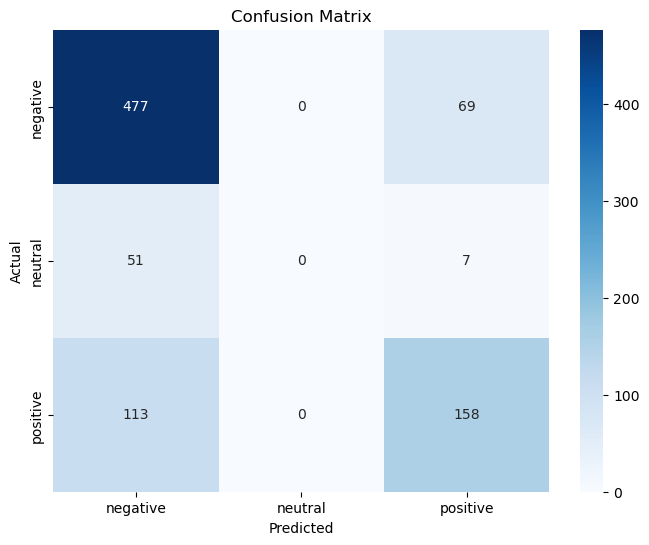

Generating explainability insights...
28/28 [==============================] - 19s 385ms/step


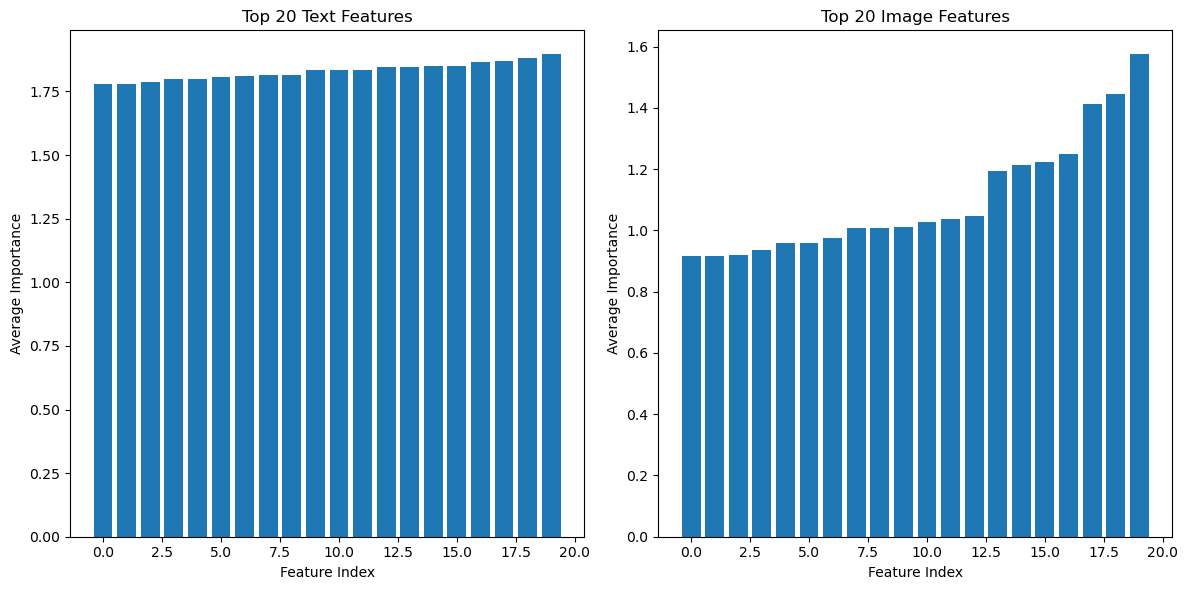

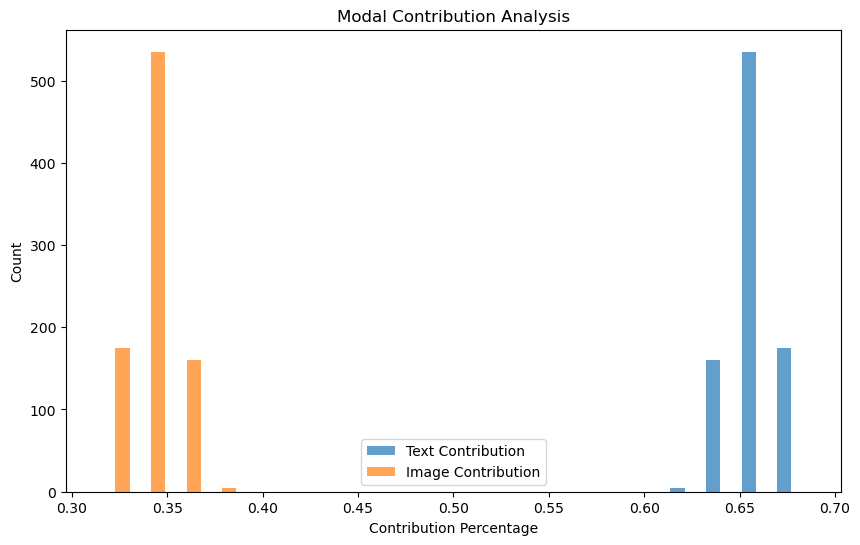

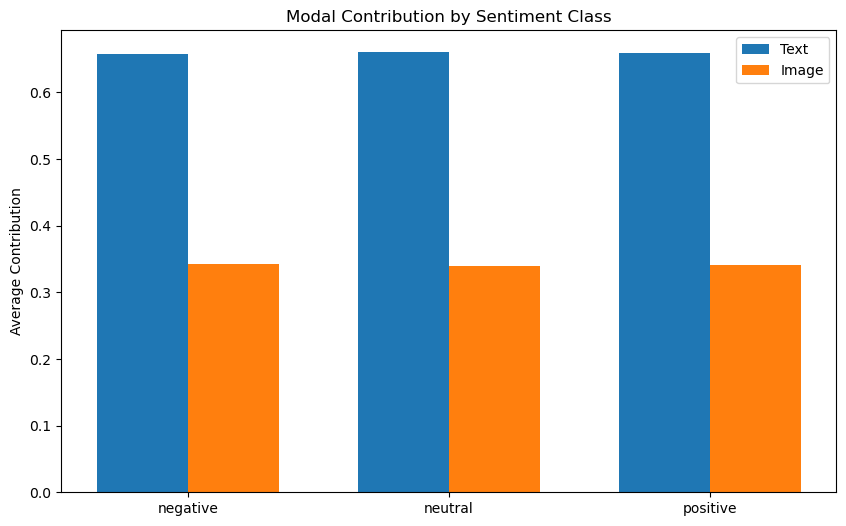


Sample 454:
Text: ??????? ???? ???? ????? ???? ???? ?? ????? ?? ??? ??    ???? ????? ?? ????  
Image: /kaggle/input/memosen-with-label/Memes/ovodro_img (678).jpg
True label: negative
Predicted label: negative
Text contribution: 0.65
Image contribution: 0.35


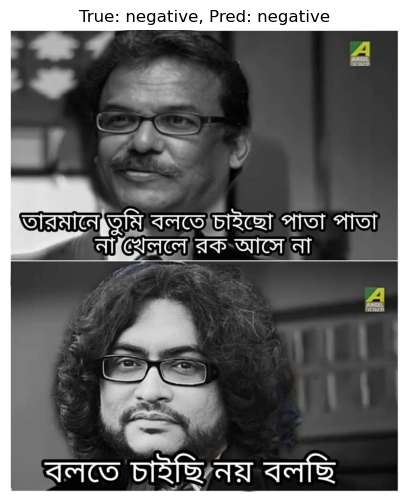


Sample 376:
Text: ????? ??? ????? ?? ??? ?????? ??? ?????? ??? ???? ??? ???   ???????
Image: /kaggle/input/memosen-with-label/Memes/Bangla Thug Life (381).jpg
True label: negative
Predicted label: negative
Text contribution: 0.66
Image contribution: 0.34


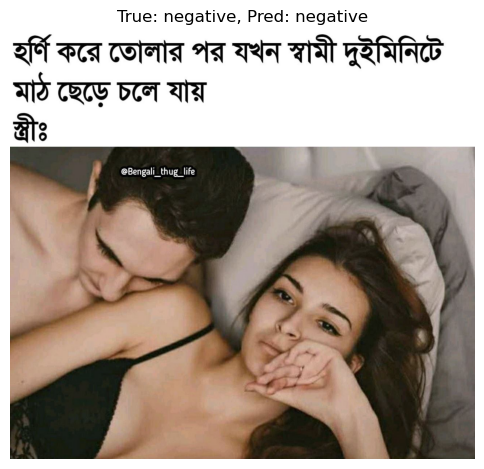


Sample 767:
Text: We Are Not Same Bro    You Love Skinny Girls   I Love Chubby Girls 
Image: /kaggle/input/memosen-with-label/Memes/bamboo-vaiya (296).jpg
True label: negative
Predicted label: negative
Text contribution: 0.65
Image contribution: 0.35


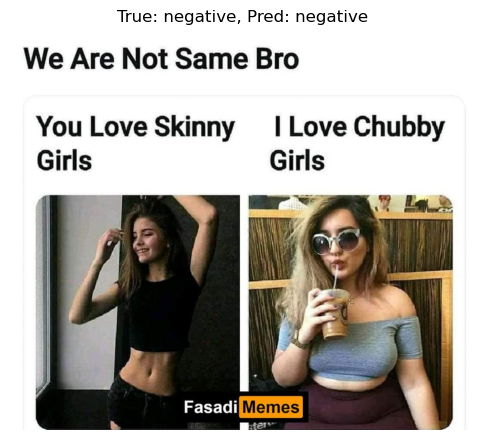


Sample 577:
Text: ?????? ??? ??? ??????????? ??????? ?? ??? ?????? ???? ????? ??? ????? ????? ???? ??????? ?? ??????? 
Image: /kaggle/input/memosen-with-label/Memes/KAM (783).jpg
True label: positive
Predicted label: positive
Text contribution: 0.66
Image contribution: 0.34


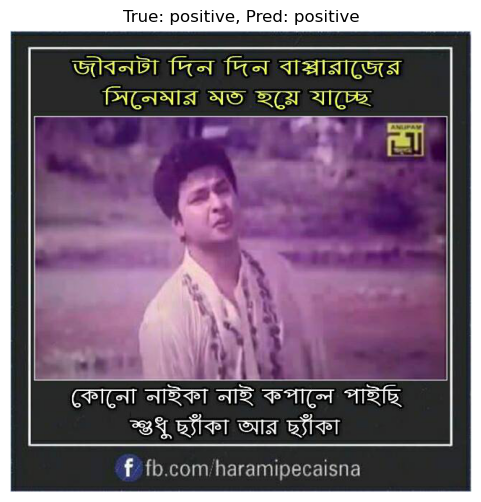


Sample 576:
Text: ?? ???? ????? ?? ??? ???? ???? ? ???,??? ?? ???? ?? ??? ?? ??? ????? ?? ???? ???????? ???!?? ?? ??? ??????? ????, ????? ??? ??!
Image: /kaggle/input/memosen-with-label/Memes/KAM (65).png
True label: positive
Predicted label: positive
Text contribution: 0.66
Image contribution: 0.34


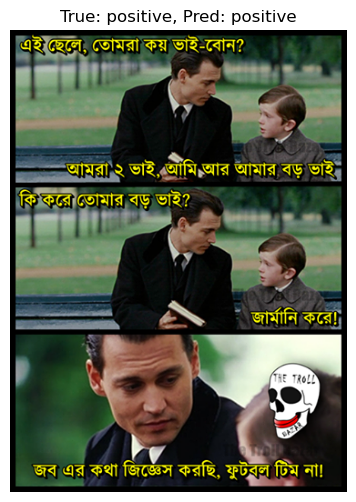

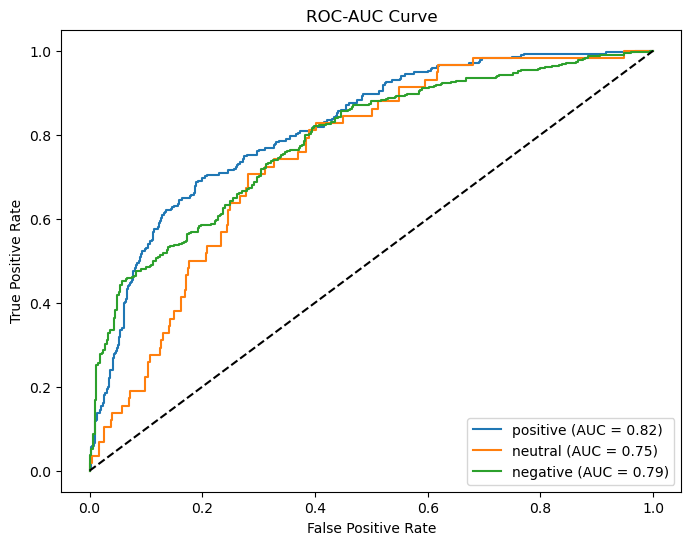

28/28 [==============================] - 11s 399ms/step
Predictions saved to submission.csv
Model report saved to model_report.txt


In [4]:
import tensorflow as tf
import numpy as np
import pandas as pd
from transformers import CLIPProcessor, TFCLIPModel, TFBertModel, BertTokenizer
from tensorflow.keras.layers import Dense, Input, Dropout, LayerNormalization, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from PIL import Image
import os
from tqdm import tqdm


from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, precision_recall_curve, auc, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.layers import MultiHeadAttention, Concatenate, GlobalAveragePooling1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import MultiHeadAttention, Concatenate, Dense, Input, Dropout, LayerNormalization

def load_data(train_path, test_path):
    """Load training and test data"""
    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)
    return train_df, test_df

def get_image_paths(directory, image_names):
    """Get full paths for images"""
    image_paths = {img: os.path.join(directory, img) for img in image_names}
    return [image_paths[img] for img in image_names if img in image_paths]

from transformers import AutoTokenizer, TFBertModel  # Changed to AutoTokenizer

class MultimodalSentimentModel:
    def __init__(self, num_classes=3):
        self.num_classes = num_classes
        
        # Image model (CLIP) - unchanged
        self.clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
        self.clip_model = TFCLIPModel.from_pretrained("openai/clip-vit-base-patch32")
        self.clip_model.trainable = False

        # Text model (Bangla-BERT)
        self.bert_tokenizer = AutoTokenizer.from_pretrained("sagorsarker/bangla-bert-base")
        self.bert_model = TFBertModel.from_pretrained("sagorsarker/bangla-bert-base")
        self.bert_model.trainable = False  # Freeze BERT layers
        
        # Set max lengths
        self.max_text_length = 128  # Can increase to 256 if needed

    # Rest of the class remains the same except for text processing
    def process_text_batch(self, texts):
        """Process Bengali text through Bangla-BERT tokenizer"""
        inputs = self.bert_tokenizer(
            texts,
            return_tensors="tf",
            padding='max_length',
            truncation=True,
            max_length=self.max_text_length
        )
        return inputs
    
    def process_image_batch(self, images):
        """Process a batch of images through CLIP image processor"""
        inputs = self.clip_processor(
            images=images,
            return_tensors="tf",
            padding='max_length',
            truncation=True,
        )
        return {'pixel_values': inputs['pixel_values']}

    def cross_modal_attention(text_features, image_features, projection_dim=128):
        # Project both modalities to same space
        text_proj = Dense(projection_dim)(text_features)
        image_proj = Dense(projection_dim)(image_features)
        
        # Cross-attention layers
        attn_output = MultiHeadAttention(num_heads=4, key_dim=projection_dim)(
            query=text_proj, value=image_proj, key=image_proj
        )
        attn_output = GlobalAveragePooling1D()(attn_output)
        return attn_output

    def build_model(self):
        # Text inputs (BERT)
        input_ids = Input(shape=(self.max_text_length,), dtype=tf.int32, name='input_ids')
        attention_mask = Input(shape=(self.max_text_length,), dtype=tf.int32, name='attention_mask')
        
        # Image inputs (CLIP)
        pixel_values = Input(shape=(3, 224, 224), dtype=tf.float32, name='pixel_values')
        
        # Get BERT text embeddings
        bert_outputs = self.bert_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        text_features = bert_outputs.pooler_output  # [batch_size, 768]
        
        # Get CLIP image embeddings
        batch_size = tf.shape(pixel_values)[0]
        empty_input_ids = tf.zeros((batch_size, 1), dtype=tf.int32)
        clip_outputs = self.clip_model(
            input_ids=empty_input_ids,
            pixel_values=pixel_values,
            attention_mask=None
        )
        image_features = clip_outputs.image_embeds  # [batch_size, 512]
        
        # Normalize embeddings
        text_features = LayerNormalization(epsilon=1e-6)(text_features)
        image_features = LayerNormalization(epsilon=1e-6)(image_features)
    
        # Project CLIP embeddings to match BERT dimension
        image_features = Dense(768, activation='gelu')(image_features)
        image_features = Dropout(0.2)(image_features)
    
        # Cross-modal attention mechanism
        def cross_modal_fusion(query, key, value, projection_dim=128):
            """Enhanced cross-attention with residual connections"""
            # Project to common space
            query_proj = Dense(projection_dim)(query)
            key_proj = Dense(projection_dim)(key)
            value_proj = Dense(projection_dim)(value)
            
            # Add sequence dimension for attention
            query_proj = tf.expand_dims(query_proj, 1)  # [bs, 1, dim]
            key_proj = tf.expand_dims(key_proj, 1)      # [bs, 1, dim]
            value_proj = tf.expand_dims(value_proj, 1)  # [bs, 1, dim]
            
            # Multi-head attention
            attn_output, _ = MultiHeadAttention(
                num_heads=8,
                key_dim=projection_dim//8,
                dropout=0.1
            )(query_proj, key_proj, value_proj, return_attention_scores=True)
            
            # Remove sequence dimension and project back
            attn_output = tf.squeeze(attn_output, 1)  # [bs, dim]
            attn_output = Dense(query.shape[-1])(attn_output)  # Project back to original dim
            
            # Residual connection + layer norm
            return LayerNormalization(epsilon=1e-6)(query + attn_output)
        
        # Bidirectional cross-attention
        text_enhanced = cross_modal_fusion(text_features, image_features, image_features)
        image_enhanced = cross_modal_fusion(image_features, text_features, text_features)
        
        # Multimodal fusion
        combined = Concatenate()([
            text_enhanced, 
            image_enhanced,
            text_features - image_features,  # Difference features
            text_features * image_features   # Hadamard product
        ])
        
        # Enhanced classification head
        x = Dense(1024, activation='gelu')(combined)
        x = Dropout(0.5)(x)
        x = LayerNormalization(epsilon=1e-6)(x)
        
        x = Dense(512, activation='gelu')(x)
        x = Dropout(0.4)(x)
        x = LayerNormalization(epsilon=1e-6)(x)
        
        x = Dense(256, activation='gelu')(x)
        x = Dropout(0.3)(x)
        x = LayerNormalization(epsilon=1e-6)(x)
        
        # Output layer
        logits = Dense(self.num_classes, activation=None)(x)  # No activation here
        outputs = tf.keras.layers.Softmax(axis=-1)(logits)  # Explicit softmax on last axis
        
        # Create final model
        model = Model(
            inputs=[input_ids, attention_mask, pixel_values],
            outputs=outputs
        )
        
        # Create activation model for explainability
        activation_model = Model(
            inputs=[input_ids, attention_mask, pixel_values],
            outputs=[outputs, image_features, text_features, combined]
        )
        
        # Configure optimizer with warmup
        optimizer = Adam(
            learning_rate=3e-5,
            decay=1e-4
        )
        
        model.compile(
            optimizer=optimizer,
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'],
            weighted_metrics=['accuracy']
        )
        
        return model, activation_model

def process_data_batch(image_paths, texts, model_handler, batch_size=32):
    """Process data in batches to avoid memory issues"""
    # Process text data with BERT
    text_inputs = model_handler.process_text_batch(texts)
    
    # Process images in batches
    all_image_inputs = []
    for i in range(0, len(image_paths), batch_size):
        batch_images = []
        # Load images for current batch
        for path in image_paths[i:i + batch_size]:
            try:
                image = Image.open(path).convert('RGB')
                batch_images.append(image)
            except Exception as e:
                print(f"Error loading image {path}: {str(e)}")
                # Create a blank image as fallback
                batch_images.append(Image.new('RGB', (224, 224), color='black'))
        
        # Process batch of images
        batch_image_inputs = model_handler.process_image_batch(batch_images)
        all_image_inputs.append(batch_image_inputs['pixel_values'])
    
    # Combine all image batches
    combined_pixel_values = tf.concat(all_image_inputs, axis=0)
    
    # Combine all inputs
    combined_inputs = {
        'input_ids': text_inputs['input_ids'],
        'attention_mask': text_inputs['attention_mask'],
        'pixel_values': combined_pixel_values
    }
    
    return combined_inputs

def train_model(train_image_paths, train_texts, train_labels, 
                val_image_paths, val_texts, val_labels, epochs=20):
    # Create model instance
    model_handler = MultimodalSentimentModel()
    model, activation_model = model_handler.build_model()
    
    # Print model summary for debugging
    print("Model architecture summary:")
    model.summary()
    
    print("Processing training data...")
    train_inputs = process_data_batch(train_image_paths, train_texts, model_handler)
    
    print("Processing validation data...")
    val_inputs = process_data_batch(val_image_paths, val_texts, model_handler)
    
    # Callbacks
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=5,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.2,
            patience=3,
            min_lr=1e-6
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath='best_model.h5',
            monitor='val_accuracy',
            save_best_only=True,
            save_weights_only=False
        )
    ]
    
    # Train model
    history = model.fit(
        train_inputs,
        train_labels,
        validation_data=(val_inputs, val_labels),
        epochs=epochs,
        batch_size=32,
        # callbacks=callbacks
    )
    
    return model, activation_model, history, model_handler

def evaluate_model(model, activation_model, test_inputs, test_labels, test_texts, test_image_paths, label_map, model_handler):
    # Make predictions
    predictions = model.predict(test_inputs)
    predicted_labels = np.argmax(predictions, axis=1)
    
    # Calculate standard metrics
    precision = precision_score(test_labels, predicted_labels, average='macro')
    recall = recall_score(test_labels, predicted_labels, average='macro')
    f1 = f1_score(test_labels, predicted_labels, average='macro')
    weighted_f1 = f1_score(test_labels, predicted_labels, average='weighted')
    
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"Weighted F1-Score: {weighted_f1:.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(test_labels, predicted_labels)
    plt.figure(figsize=(8, 6))
    reverse_label_map = {v: k for k, v in label_map.items()}
    label_names = [reverse_label_map[i] for i in sorted(label_map.values())]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.savefig('confusion_matrix.png')
    plt.show()
    
    # Prepare data for explainability
    print("Generating explainability insights...")
    
    # Get intermediate activations for explainability
    [predictions, image_features, text_features, combined_features] = activation_model.predict(test_inputs)
    
    # 1. Feature Importance Visualization
    # Sample a small subset for visualization (first 100 samples or fewer)
    sample_size = min(100, len(test_labels))
    
    # Feature importance based on embeddings
    plt.figure(figsize=(12, 6))
    
    # Calculate the average absolute values of features
    avg_text_importance = np.mean(np.abs(text_features[:sample_size]), axis=0)
    avg_image_importance = np.mean(np.abs(image_features[:sample_size]), axis=0)
    
    # Plot top 20 important features for each modality
    plt.subplot(1, 2, 1)
    top_text_idx = np.argsort(avg_text_importance)[-20:]
    plt.bar(range(20), avg_text_importance[top_text_idx])
    plt.title('Top 20 Text Features')
    plt.xlabel('Feature Index')
    plt.ylabel('Average Importance')
    
    plt.subplot(1, 2, 2)
    top_img_idx = np.argsort(avg_image_importance)[-20:]
    plt.bar(range(20), avg_image_importance[top_img_idx])
    plt.title('Top 20 Image Features')
    plt.xlabel('Feature Index')
    plt.ylabel('Average Importance')
    
    plt.tight_layout()
    plt.savefig('feature_importance.png')
    plt.show()
    
    # 2. Modal Contribution Analysis
    # Calculate modal contributions by comparing the magnitude of text vs. image features
    text_magnitude = np.linalg.norm(text_features, axis=1)
    image_magnitude = np.linalg.norm(image_features, axis=1)
    total_magnitude = text_magnitude + image_magnitude
    text_contribution = text_magnitude / total_magnitude
    image_contribution = image_magnitude / total_magnitude
    
    # Plot distribution of modal contributions
    plt.figure(figsize=(10, 6))
    plt.hist([text_contribution, image_contribution], bins=20, alpha=0.7, 
             label=['Text Contribution', 'Image Contribution'])
    plt.xlabel('Contribution Percentage')
    plt.ylabel('Count')
    plt.title('Modal Contribution Analysis')
    plt.legend()
    plt.savefig('modal_contributions.png')
    plt.show()
    
    # 3. Per-class modal contribution
    class_contributions = {}
    for label in np.unique(test_labels):
        class_mask = test_labels == label
        class_contributions[reverse_label_map[label]] = {
            'text': np.mean(text_contribution[class_mask]),
            'image': np.mean(image_contribution[class_mask])
        }
    
    # Plot per-class modal contributions
    plt.figure(figsize=(10, 6))
    labels = list(class_contributions.keys())
    text_contribs = [class_contributions[label]['text'] for label in labels]
    image_contribs = [class_contributions[label]['image'] for label in labels]
    
    x = np.arange(len(labels))
    width = 0.35
    
    plt.bar(x - width/2, text_contribs, width, label='Text')
    plt.bar(x + width/2, image_contribs, width, label='Image')
    
    plt.ylabel('Average Contribution')
    plt.title('Modal Contribution by Sentiment Class')
    plt.xticks(x, labels)
    plt.legend()
    plt.savefig('class_modal_contributions.png')
    plt.show()
    
    # 4. Sample-level analysis
    # Select a few samples for detailed analysis
    num_samples = min(5, len(test_labels))
    indices = np.random.choice(len(test_labels), num_samples, replace=False)
    
    for idx in indices:
        true_label = reverse_label_map[test_labels[idx]]
        pred_label = reverse_label_map[predicted_labels[idx]]
        text = test_texts[idx]
        img_path = test_image_paths[idx]
        
        # Show sample information
        print(f"\nSample {idx+1}:")
        print(f"Text: {text}")
        print(f"Image: {img_path}")
        print(f"True label: {true_label}")
        print(f"Predicted label: {pred_label}")
        print(f"Text contribution: {text_contribution[idx]:.2f}")
        print(f"Image contribution: {image_contribution[idx]:.2f}")
        
        # Display image
        try:
            img = Image.open(img_path).convert('RGB')
            plt.figure(figsize=(6, 6))
            plt.imshow(img)
            plt.title(f"True: {true_label}, Pred: {pred_label}")
            plt.axis('off')
            plt.show()
        except Exception as e:
            print(f"Error displaying image: {e}")
    
    # 5. ROC-AUC Curve
    y_test_one_hot = tf.keras.utils.to_categorical(test_labels, num_classes=len(label_map))
    fpr = {}
    tpr = {}
    roc_auc = {}
    
    for i, label in enumerate(sorted(label_map.values())):
        label_name = reverse_label_map[label]
        fpr[label_name], tpr[label_name], _ = roc_curve(y_test_one_hot[:, i], predictions[:, i])
        roc_auc[label_name] = auc(fpr[label_name], tpr[label_name])
    
    plt.figure(figsize=(8, 6))
    for label_name in reverse_label_map.values():
        plt.plot(fpr[label_name], tpr[label_name], label=f'{label_name} (AUC = {roc_auc[label_name]:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line for random guessing
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC-AUC Curve')
    plt.legend(loc='lower right')
    plt.savefig('roc_auc_curve.png')
    plt.show()
    
    # Return metrics for further analysis if needed
    return {
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'weighted_f1': weighted_f1,
        'confusion_matrix': cm,
        'text_contribution': text_contribution,
        'image_contribution': image_contribution,
        'class_contributions': class_contributions
    }

def main():
    # Load the combined dataset with the correct encoding
    try:
        combined_df = pd.read_csv('/kaggle/input/memosen-with-label/multi-sent.csv', encoding='utf-8')
    except UnicodeDecodeError:
        # Try alternative encodings if UTF-8 fails
        try:
            combined_df = pd.read_csv('/kaggle/input/memosen-with-label/multi-sent.csv', encoding='latin-1')
        except Exception as e:
            print(f"Failed to read the CSV file: {e}")
            return
    
    # Debug: Print column names to verify
    print("Combined DataFrame Columns:", combined_df.columns)
    
    # Ensure the label column exists
    if 'Label_Sentiment' not in combined_df.columns:
        raise KeyError("Column 'Label_Sentiment' not found in the combined dataset. Please check the column names.")
    
    # Check for missing or invalid values in the 'Label_Sentiment' column
    print("Number of missing values in 'Label_Sentiment':", combined_df['Label_Sentiment'].isna().sum())
    print("Unique values in 'Label_Sentiment':", combined_df['Label_Sentiment'].unique())
    
    # Drop rows with missing or invalid labels
    valid_labels = ['positive', 'neutral', 'negative']
    combined_df = combined_df[combined_df['Label_Sentiment'].isin(valid_labels)]
    
    # Check if the dataset is empty after cleaning
    if combined_df.empty:
        raise ValueError("The dataset is empty after removing rows with invalid labels.")
    
    # Convert labels to numerical values
    label_map = {'positive': 2, 'neutral': 1, 'negative': 0}
    combined_df['Label_Sentiment'] = combined_df['Label_Sentiment'].map(label_map)
    
    # Split the data into train and test sets (80-20 ratio)
    train_df, test_df = train_test_split(
        combined_df, test_size=0.2, random_state=42, stratify=combined_df['Label_Sentiment']
    )
    
    # Further split train into train and validation
    train_df, val_df = train_test_split(
        train_df, test_size=0.15, random_state=42, stratify=train_df['Label_Sentiment']
    )
    
    # Copy the labels of the test set for evaluation
    test_labels_df = test_df[['Label_Sentiment']].copy()
    val_labels_df = val_df[['Label_Sentiment']].copy()
    
    # Get image paths
    memes_folder = '/kaggle/input/memosen-with-label/Memes'
    train_image_paths = get_image_paths(memes_folder, train_df['image_name'].tolist())
    val_image_paths = get_image_paths(memes_folder, val_df['image_name'].tolist())
    test_image_paths = get_image_paths(memes_folder, test_df['image_name'].tolist())
    
    # Extract labels
    train_labels = train_df['Label_Sentiment'].values
    val_labels = val_labels_df['Label_Sentiment'].values
    test_labels = test_labels_df['Label_Sentiment'].values
    
    # Train model
    model, activation_model, history, model_handler = train_model(
        train_image_paths, train_df['Captions'].tolist(), train_labels,
        val_image_paths, val_df['Captions'].tolist(), val_labels
    )
    
    # Process test data
    print("Processing test data...")
    test_inputs = process_data_batch(test_image_paths, test_df['Captions'].tolist(), model_handler)
    
    # Evaluate model on the test set with explainability
    metrics = evaluate_model(
        model, 
        activation_model,
        test_inputs, 
        test_labels, 
        test_df['Captions'].tolist(),
        test_image_paths,
        label_map,
        model_handler
    )
    
    # Make predictions
    predictions = model.predict(test_inputs)
    predicted_labels = np.argmax(predictions, axis=1)
    
    # Convert predictions to original labels
    reverse_label_map = {v: k for k, v in label_map.items()}
    test_df['Label'] = [reverse_label_map[label] for label in predicted_labels]
    
    # Check if 'Id' column exists in test_df
    if 'Id' not in test_df.columns:
        # Create a unique identifier if 'Id' column is missing
        test_df['Id'] = range(1, len(test_df) + 1)
        print("Warning: 'Id' column not found in test_df. A unique identifier has been created.")
    
    # Save predictions
    test_df[['Id', 'Label']].to_csv('submission.csv', index=False)
    print("Predictions saved to submission.csv")
    
    # Save model summary and performance metrics
    with open('model_report.txt', 'w') as f:
        # Model architecture summary
        model.summary(print_fn=lambda x: f.write(x + '\n'))
        
        # Performance metrics
        f.write("\n\nPERFORMANCE METRICS\n")
        f.write(f"Precision: {metrics['precision']:.4f}\n")
        f.write(f"Recall: {metrics['recall']:.4f}\n")
        f.write(f"F1-Score: {metrics['f1']:.4f}\n")
        f.write(f"Weighted F1-Score: {metrics['weighted_f1']:.4f}\n")
        
        # Modal contribution analysis
        f.write("\n\nMODAL CONTRIBUTION ANALYSIS\n")
        f.write("Average contribution by modality:\n")
        f.write(f"Text: {np.mean(metrics['text_contribution']):.4f}\n")
        f.write(f"Image: {np.mean(metrics['image_contribution']):.4f}\n")
        
        f.write("\nContribution by class:\n")
        for label, contributions in metrics['class_contributions'].items():
            f.write(f"{label}: Text {contributions['text']:.4f}, Image {contributions['image']:.4f}\n")
    
    print("Model report saved to model_report.txt")
    
    return model, activation_model, history, metrics

if __name__ == "__main__":
    main()

# Added Bangla-BERT (sagorsarker/bangla-bert-base)

- Enhanced Multimodal Fusion Architecture
- Replace simple concatenation with cross-modal attention

batch size: 16  
accuracy: 0.7446  
val_accuracy: 0.7086  
Precision: 0.4677  
Recall: 0.4720  
F1-Score: 0.4648  
Weighted F1-Score: 0.6826      

In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
from transformers import CLIPProcessor, TFCLIPModel, TFBertModel, BertTokenizer
from tensorflow.keras.layers import Dense, Input, Dropout, LayerNormalization, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from PIL import Image
import os
from tqdm import tqdm


from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, precision_recall_curve, auc, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.layers import MultiHeadAttention, Concatenate, GlobalAveragePooling1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import MultiHeadAttention, Concatenate, Dense, Input, Dropout, LayerNormalization

def load_data(train_path, test_path):
    """Load training and test data"""
    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)
    return train_df, test_df

def get_image_paths(directory, image_names):
    """Get full paths for images"""
    image_paths = {img: os.path.join(directory, img) for img in image_names}
    return [image_paths[img] for img in image_names if img in image_paths]

from transformers import AutoTokenizer, TFBertModel  # Changed to AutoTokenizer

class MultimodalSentimentModel:
    def __init__(self, num_classes=3):
        self.num_classes = num_classes
        
        # Image model (CLIP) - unchanged
        self.clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
        self.clip_model = TFCLIPModel.from_pretrained("openai/clip-vit-base-patch32")
        self.clip_model.trainable = False

        # Text model (Bangla-BERT)
        self.bert_tokenizer = AutoTokenizer.from_pretrained("sagorsarker/bangla-bert-base")
        self.bert_model = TFBertModel.from_pretrained("sagorsarker/bangla-bert-base")
        self.bert_model.trainable = False  # Freeze BERT layers
        
        # Set max lengths
        self.max_text_length = 128  # Can increase to 256 if needed

    # Rest of the class remains the same except for text processing
    def process_text_batch(self, texts):
        """Process Bengali text through Bangla-BERT tokenizer"""
        inputs = self.bert_tokenizer(
            texts,
            return_tensors="tf",
            padding='max_length',
            truncation=True,
            max_length=self.max_text_length
        )
        return inputs
    
    def process_image_batch(self, images):
        """Process a batch of images through CLIP image processor"""
        inputs = self.clip_processor(
            images=images,
            return_tensors="tf",
            padding='max_length',
            truncation=True,
        )
        return {'pixel_values': inputs['pixel_values']}

    def cross_modal_attention(text_features, image_features, projection_dim=128):
        # Project both modalities to same space
        text_proj = Dense(projection_dim)(text_features)
        image_proj = Dense(projection_dim)(image_features)
        
        # Cross-attention layers
        attn_output = MultiHeadAttention(num_heads=4, key_dim=projection_dim)(
            query=text_proj, value=image_proj, key=image_proj
        )
        attn_output = GlobalAveragePooling1D()(attn_output)
        return attn_output

    def build_model(self):
        # Text inputs (BERT)
        input_ids = Input(shape=(self.max_text_length,), dtype=tf.int32, name='input_ids')
        attention_mask = Input(shape=(self.max_text_length,), dtype=tf.int32, name='attention_mask')
        
        # Image inputs (CLIP)
        pixel_values = Input(shape=(3, 224, 224), dtype=tf.float32, name='pixel_values')
        
        # Get BERT text embeddings
        bert_outputs = self.bert_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        text_features = bert_outputs.pooler_output  # [batch_size, 768]
        
        # Get CLIP image embeddings
        batch_size = tf.shape(pixel_values)[0]
        empty_input_ids = tf.zeros((batch_size, 1), dtype=tf.int32)
        clip_outputs = self.clip_model(
            input_ids=empty_input_ids,
            pixel_values=pixel_values,
            attention_mask=None
        )
        image_features = clip_outputs.image_embeds  # [batch_size, 512]
        
        # Normalize embeddings
        text_features = LayerNormalization(epsilon=1e-6)(text_features)
        image_features = LayerNormalization(epsilon=1e-6)(image_features)
    
        # Project CLIP embeddings to match BERT dimension
        image_features = Dense(768, activation='gelu')(image_features)
        image_features = Dropout(0.2)(image_features)
    
        # Cross-modal attention mechanism
        def cross_modal_fusion(query, key, value, projection_dim=128):
            """Enhanced cross-attention with residual connections"""
            # Project to common space
            query_proj = Dense(projection_dim)(query)
            key_proj = Dense(projection_dim)(key)
            value_proj = Dense(projection_dim)(value)
            
            # Add sequence dimension for attention
            query_proj = tf.expand_dims(query_proj, 1)  # [bs, 1, dim]
            key_proj = tf.expand_dims(key_proj, 1)      # [bs, 1, dim]
            value_proj = tf.expand_dims(value_proj, 1)  # [bs, 1, dim]
            
            # Multi-head attention
            attn_output, _ = MultiHeadAttention(
                num_heads=8,
                key_dim=projection_dim//8,
                dropout=0.1
            )(query_proj, key_proj, value_proj, return_attention_scores=True)
            
            # Remove sequence dimension and project back
            attn_output = tf.squeeze(attn_output, 1)  # [bs, dim]
            attn_output = Dense(query.shape[-1])(attn_output)  # Project back to original dim
            
            # Residual connection + layer norm
            return LayerNormalization(epsilon=1e-6)(query + attn_output)
        
        # Bidirectional cross-attention
        text_enhanced = cross_modal_fusion(text_features, image_features, image_features)
        image_enhanced = cross_modal_fusion(image_features, text_features, text_features)
        
        # Multimodal fusion
        combined = Concatenate()([
            text_enhanced, 
            image_enhanced,
            text_features - image_features,  # Difference features
            text_features * image_features   # Hadamard product
        ])
        
        # Enhanced classification head
        x = Dense(768, activation='gelu')(combined)
        x = Dropout(0.4)(x)
        x = LayerNormalization(epsilon=1e-6)(x)
        
        x = Dense(384, activation='gelu')(x)
        x = Dropout(0.3)(x)
        x = LayerNormalization(epsilon=1e-6)(x)
        
        # Output layer
        logits = Dense(self.num_classes, activation=None)(x)  # No activation here
        outputs = tf.keras.layers.Softmax(axis=-1)(logits)  # Explicit softmax on last axis
        
        # Create final model
        model = Model(
            inputs=[input_ids, attention_mask, pixel_values],
            outputs=outputs
        )
        
        # Create activation model for explainability
        activation_model = Model(
            inputs=[input_ids, attention_mask, pixel_values],
            outputs=[outputs, image_features, text_features, combined]
        )
        
        # Configure optimizer with warmup
        optimizer = Adam(
            learning_rate=3e-5,
            decay=1e-4
        )
        
        model.compile(
            optimizer=optimizer,
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'],
            weighted_metrics=['accuracy']
        )
        
        return model, activation_model

def process_data_batch(image_paths, texts, model_handler, batch_size=32):
    """Process data in batches to avoid memory issues"""
    # Process text data with BERT
    text_inputs = model_handler.process_text_batch(texts)
    
    # Process images in batches
    all_image_inputs = []
    for i in range(0, len(image_paths), batch_size):
        batch_images = []
        # Load images for current batch
        for path in image_paths[i:i + batch_size]:
            try:
                image = Image.open(path).convert('RGB')
                batch_images.append(image)
            except Exception as e:
                print(f"Error loading image {path}: {str(e)}")
                # Create a blank image as fallback
                batch_images.append(Image.new('RGB', (224, 224), color='black'))
        
        # Process batch of images
        batch_image_inputs = model_handler.process_image_batch(batch_images)
        all_image_inputs.append(batch_image_inputs['pixel_values'])
    
    # Combine all image batches
    combined_pixel_values = tf.concat(all_image_inputs, axis=0)
    
    # Combine all inputs
    combined_inputs = {
        'input_ids': text_inputs['input_ids'],
        'attention_mask': text_inputs['attention_mask'],
        'pixel_values': combined_pixel_values
    }
    
    return combined_inputs

def train_model(train_image_paths, train_texts, train_labels, 
                val_image_paths, val_texts, val_labels, epochs=20):
    # Create model instance
    model_handler = MultimodalSentimentModel()
    model, activation_model = model_handler.build_model()
    
    # Print model summary for debugging
    print("Model architecture summary:")
    model.summary()
    
    print("Processing training data...")
    train_inputs = process_data_batch(train_image_paths, train_texts, model_handler)
    
    print("Processing validation data...")
    val_inputs = process_data_batch(val_image_paths, val_texts, model_handler)
    
    # Callbacks
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=5,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.2,
            patience=3,
            min_lr=1e-6
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath='best_model.h5',
            monitor='val_accuracy',
            save_best_only=True,
            save_weights_only=False
        )
    ]
    
    # Train model
    history = model.fit(
        train_inputs,
        train_labels,
        validation_data=(val_inputs, val_labels),
        epochs=epochs,
        batch_size=16,
        callbacks=callbacks
    )
    
    return model, activation_model, history, model_handler

def evaluate_model(model, activation_model, test_inputs, test_labels, test_texts, test_image_paths, label_map, model_handler):
    # Make predictions
    predictions = model.predict(test_inputs)
    predicted_labels = np.argmax(predictions, axis=1)
    
    # Calculate standard metrics
    precision = precision_score(test_labels, predicted_labels, average='macro')
    recall = recall_score(test_labels, predicted_labels, average='macro')
    f1 = f1_score(test_labels, predicted_labels, average='macro')
    weighted_f1 = f1_score(test_labels, predicted_labels, average='weighted')
    
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"Weighted F1-Score: {weighted_f1:.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(test_labels, predicted_labels)
    plt.figure(figsize=(8, 6))
    reverse_label_map = {v: k for k, v in label_map.items()}
    label_names = [reverse_label_map[i] for i in sorted(label_map.values())]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.savefig('confusion_matrix.png')
    plt.show()
    
    # Prepare data for explainability
    print("Generating explainability insights...")
    
    # Get intermediate activations for explainability
    [predictions, image_features, text_features, combined_features] = activation_model.predict(test_inputs)
    
    # 1. Feature Importance Visualization
    # Sample a small subset for visualization (first 100 samples or fewer)
    sample_size = min(100, len(test_labels))
    
    # Feature importance based on embeddings
    plt.figure(figsize=(12, 6))
    
    # Calculate the average absolute values of features
    avg_text_importance = np.mean(np.abs(text_features[:sample_size]), axis=0)
    avg_image_importance = np.mean(np.abs(image_features[:sample_size]), axis=0)
    
    # Plot top 20 important features for each modality
    plt.subplot(1, 2, 1)
    top_text_idx = np.argsort(avg_text_importance)[-20:]
    plt.bar(range(20), avg_text_importance[top_text_idx])
    plt.title('Top 20 Text Features')
    plt.xlabel('Feature Index')
    plt.ylabel('Average Importance')
    
    plt.subplot(1, 2, 2)
    top_img_idx = np.argsort(avg_image_importance)[-20:]
    plt.bar(range(20), avg_image_importance[top_img_idx])
    plt.title('Top 20 Image Features')
    plt.xlabel('Feature Index')
    plt.ylabel('Average Importance')
    
    plt.tight_layout()
    plt.savefig('feature_importance.png')
    plt.show()
    
    # 2. Modal Contribution Analysis
    # Calculate modal contributions by comparing the magnitude of text vs. image features
    text_magnitude = np.linalg.norm(text_features, axis=1)
    image_magnitude = np.linalg.norm(image_features, axis=1)
    total_magnitude = text_magnitude + image_magnitude
    text_contribution = text_magnitude / total_magnitude
    image_contribution = image_magnitude / total_magnitude
    
    # Plot distribution of modal contributions
    plt.figure(figsize=(10, 6))
    plt.hist([text_contribution, image_contribution], bins=20, alpha=0.7, 
             label=['Text Contribution', 'Image Contribution'])
    plt.xlabel('Contribution Percentage')
    plt.ylabel('Count')
    plt.title('Modal Contribution Analysis')
    plt.legend()
    plt.savefig('modal_contributions.png')
    plt.show()
    
    # 3. Per-class modal contribution
    class_contributions = {}
    for label in np.unique(test_labels):
        class_mask = test_labels == label
        class_contributions[reverse_label_map[label]] = {
            'text': np.mean(text_contribution[class_mask]),
            'image': np.mean(image_contribution[class_mask])
        }
    
    # Plot per-class modal contributions
    plt.figure(figsize=(10, 6))
    labels = list(class_contributions.keys())
    text_contribs = [class_contributions[label]['text'] for label in labels]
    image_contribs = [class_contributions[label]['image'] for label in labels]
    
    x = np.arange(len(labels))
    width = 0.35
    
    plt.bar(x - width/2, text_contribs, width, label='Text')
    plt.bar(x + width/2, image_contribs, width, label='Image')
    
    plt.ylabel('Average Contribution')
    plt.title('Modal Contribution by Sentiment Class')
    plt.xticks(x, labels)
    plt.legend()
    plt.savefig('class_modal_contributions.png')
    plt.show()
    
    # 4. Sample-level analysis
    # Select a few samples for detailed analysis
    num_samples = min(5, len(test_labels))
    indices = np.random.choice(len(test_labels), num_samples, replace=False)
    
    for idx in indices:
        true_label = reverse_label_map[test_labels[idx]]
        pred_label = reverse_label_map[predicted_labels[idx]]
        text = test_texts[idx]
        img_path = test_image_paths[idx]
        
        # Show sample information
        print(f"\nSample {idx+1}:")
        print(f"Text: {text}")
        print(f"Image: {img_path}")
        print(f"True label: {true_label}")
        print(f"Predicted label: {pred_label}")
        print(f"Text contribution: {text_contribution[idx]:.2f}")
        print(f"Image contribution: {image_contribution[idx]:.2f}")
        
        # Display image
        try:
            img = Image.open(img_path).convert('RGB')
            plt.figure(figsize=(6, 6))
            plt.imshow(img)
            plt.title(f"True: {true_label}, Pred: {pred_label}")
            plt.axis('off')
            plt.show()
        except Exception as e:
            print(f"Error displaying image: {e}")
    
    # 5. ROC-AUC Curve
    y_test_one_hot = tf.keras.utils.to_categorical(test_labels, num_classes=len(label_map))
    fpr = {}
    tpr = {}
    roc_auc = {}
    
    for i, label in enumerate(sorted(label_map.values())):
        label_name = reverse_label_map[label]
        fpr[label_name], tpr[label_name], _ = roc_curve(y_test_one_hot[:, i], predictions[:, i])
        roc_auc[label_name] = auc(fpr[label_name], tpr[label_name])
    
    plt.figure(figsize=(8, 6))
    for label_name in reverse_label_map.values():
        plt.plot(fpr[label_name], tpr[label_name], label=f'{label_name} (AUC = {roc_auc[label_name]:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line for random guessing
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC-AUC Curve')
    plt.legend(loc='lower right')
    plt.savefig('roc_auc_curve.png')
    plt.show()
    
    # Return metrics for further analysis if needed
    return {
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'weighted_f1': weighted_f1,
        'confusion_matrix': cm,
        'text_contribution': text_contribution,
        'image_contribution': image_contribution,
        'class_contributions': class_contributions
    }

def main():
    # Load the combined dataset with the correct encoding
    try:
        combined_df = pd.read_csv('/kaggle/input/memosen-with-label/multi-sent.csv', encoding='utf-8')
    except UnicodeDecodeError:
        # Try alternative encodings if UTF-8 fails
        try:
            combined_df = pd.read_csv('/kaggle/input/memosen-with-label/multi-sent.csv', encoding='latin-1')
        except Exception as e:
            print(f"Failed to read the CSV file: {e}")
            return
    
    # Debug: Print column names to verify
    print("Combined DataFrame Columns:", combined_df.columns)
    
    # Ensure the label column exists
    if 'Label_Sentiment' not in combined_df.columns:
        raise KeyError("Column 'Label_Sentiment' not found in the combined dataset. Please check the column names.")
    
    # Check for missing or invalid values in the 'Label_Sentiment' column
    print("Number of missing values in 'Label_Sentiment':", combined_df['Label_Sentiment'].isna().sum())
    print("Unique values in 'Label_Sentiment':", combined_df['Label_Sentiment'].unique())
    
    # Drop rows with missing or invalid labels
    valid_labels = ['positive', 'neutral', 'negative']
    combined_df = combined_df[combined_df['Label_Sentiment'].isin(valid_labels)]
    
    # Check if the dataset is empty after cleaning
    if combined_df.empty:
        raise ValueError("The dataset is empty after removing rows with invalid labels.")
    
    # Convert labels to numerical values
    label_map = {'positive': 2, 'neutral': 1, 'negative': 0}
    combined_df['Label_Sentiment'] = combined_df['Label_Sentiment'].map(label_map)
    
    # Split the data into train and test sets (80-20 ratio)
    train_df, test_df = train_test_split(
        combined_df, test_size=0.2, random_state=42, stratify=combined_df['Label_Sentiment']
    )
    
    # Further split train into train and validation
    train_df, val_df = train_test_split(
        train_df, test_size=0.15, random_state=42, stratify=train_df['Label_Sentiment']
    )
    
    # Copy the labels of the test set for evaluation
    test_labels_df = test_df[['Label_Sentiment']].copy()
    val_labels_df = val_df[['Label_Sentiment']].copy()
    
    # Get image paths
    memes_folder = '/kaggle/input/memosen-with-label/Memes'
    train_image_paths = get_image_paths(memes_folder, train_df['image_name'].tolist())
    val_image_paths = get_image_paths(memes_folder, val_df['image_name'].tolist())
    test_image_paths = get_image_paths(memes_folder, test_df['image_name'].tolist())
    
    # Extract labels
    train_labels = train_df['Label_Sentiment'].values
    val_labels = val_labels_df['Label_Sentiment'].values
    test_labels = test_labels_df['Label_Sentiment'].values
    
    # Train model
    model, activation_model, history, model_handler = train_model(
        train_image_paths, train_df['Captions'].tolist(), train_labels,
        val_image_paths, val_df['Captions'].tolist(), val_labels
    )
    
    # Process test data
    print("Processing test data...")
    test_inputs = process_data_batch(test_image_paths, test_df['Captions'].tolist(), model_handler)
    
    # Evaluate model on the test set with explainability
    metrics = evaluate_model(
        model, 
        activation_model,
        test_inputs, 
        test_labels, 
        test_df['Captions'].tolist(),
        test_image_paths,
        label_map,
        model_handler
    )
    
    # Make predictions
    predictions = model.predict(test_inputs)
    predicted_labels = np.argmax(predictions, axis=1)
    
    # Convert predictions to original labels
    reverse_label_map = {v: k for k, v in label_map.items()}
    test_df['Label'] = [reverse_label_map[label] for label in predicted_labels]
    
    # Check if 'Id' column exists in test_df
    if 'Id' not in test_df.columns:
        # Create a unique identifier if 'Id' column is missing
        test_df['Id'] = range(1, len(test_df) + 1)
        print("Warning: 'Id' column not found in test_df. A unique identifier has been created.")
    
    # Save predictions
    test_df[['Id', 'Label']].to_csv('submission.csv', index=False)
    print("Predictions saved to submission.csv")
    
    # Save model summary and performance metrics
    with open('model_report.txt', 'w') as f:
        # Model architecture summary
        model.summary(print_fn=lambda x: f.write(x + '\n'))
        
        # Performance metrics
        f.write("\n\nPERFORMANCE METRICS\n")
        f.write(f"Precision: {metrics['precision']:.4f}\n")
        f.write(f"Recall: {metrics['recall']:.4f}\n")
        f.write(f"F1-Score: {metrics['f1']:.4f}\n")
        f.write(f"Weighted F1-Score: {metrics['weighted_f1']:.4f}\n")
        
        # Modal contribution analysis
        f.write("\n\nMODAL CONTRIBUTION ANALYSIS\n")
        f.write("Average contribution by modality:\n")
        f.write(f"Text: {np.mean(metrics['text_contribution']):.4f}\n")
        f.write(f"Image: {np.mean(metrics['image_contribution']):.4f}\n")
        
        f.write("\nContribution by class:\n")
        for label, contributions in metrics['class_contributions'].items():
            f.write(f"{label}: Text {contributions['text']:.4f}, Image {contributions['image']:.4f}\n")
    
    print("Model report saved to model_report.txt")
    
    return model, activation_model, history, metrics

if __name__ == "__main__":
    main()

# Added Bangla-BERT-Large + VIT (strong version)

- Enhanced Multimodal Hybrid Fusion Architecture

batch size: 16  
accuracy: 0.7446  
val_accuracy: 0.7086  
Precision: 0.4677  
Recall: 0.4720  
F1-Score: 0.4648  
Weighted F1-Score: 0.6826      

In [ ]:
pip install transformers==4.26.0 tensorflow==2.10.0

In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
from transformers import AutoTokenizer, TFBertModel, ViTFeatureExtractor, TFViTForImageClassification
from tensorflow.keras.layers import Dense, Input, Dropout, LayerNormalization, Concatenate, MultiHeadAttention
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from PIL import Image
import os
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def load_data(train_path, test_path):
    """Load training and test data"""
    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)
    return train_df, test_df

def get_image_paths(directory, image_names):
    """Get full paths for images"""
    return [os.path.join(directory, img) for img in image_names if os.path.exists(os.path.join(directory, img))]

class MultimodalSentimentModel:
    def __init__(self, num_classes=3):
        self.num_classes = num_classes
        
        # Image model (ViT)
        self.vit_processor = ViTFeatureExtractor.from_pretrained("google/vit-base-patch16-224-in21k")
        self.vit_model = TFViTForImageClassification.from_pretrained("google/vit-base-patch16-224-in21k")
        self.vit_model.trainable = False

        # Text model (BanglaBERT Large)
        self.bert_tokenizer = AutoTokenizer.from_pretrained("csebuetnlp/banglabert_large")
        self.bert_model = TFBertModel.from_pretrained("csebuetnlp/banglabert_large", from_pt=True)  # Convert PyTorch to TF
        self.bert_model.trainable = False
        
        self.max_text_length = 128

    def process_text_batch(self, texts):
        """Process Bengali text through Bangla-BERT tokenizer"""
        return self.bert_tokenizer(
            texts,
            return_tensors="tf",
            padding='max_length',
            truncation=True,
            max_length=self.max_text_length
        )
    
    def process_image_batch(self, images):
        """Process images through ViT processor"""
        inputs = self.vit_processor(
            images=images,
            return_tensors="tf",
            padding=True,
            truncation=True,
        )
        return {'pixel_values': inputs['pixel_values']}

    def build_model(self):
        # Text inputs
        input_ids = Input(shape=(self.max_text_length,), dtype=tf.int32, name='input_ids')
        attention_mask = Input(shape=(self.max_text_length,), dtype=tf.int32, name='attention_mask')
        
        # Image inputs
        pixel_values = Input(shape=(3, 224, 224), dtype=tf.float32, name='pixel_values')
        
        # Get text embeddings
        text_out = self.bert_model(input_ids=input_ids, attention_mask=attention_mask)
        text_features = LayerNormalization(epsilon=1e-6)(text_out.pooler_output)
        
        # Get image embeddings
        image_out = self.vit_model(pixel_values=pixel_values)
        image_features = LayerNormalization(epsilon=1e-6)(image_out.logits)
        
        # Cross-modal attention
        def cross_attn_block(query, key, value, proj_dim=256):
            # Project to common space
            q = Dense(proj_dim)(query)
            k = Dense(proj_dim)(key)
            v = Dense(proj_dim)(value)
            
            # Add sequence dimension for attention
            q = tf.expand_dims(q, 1)  # [bs, 1, dim]
            k = tf.expand_dims(k, 1)   # [bs, 1, dim]
            v = tf.expand_dims(v, 1)   # [bs, 1, dim]
            
            # Multi-head attention
            attn_output, _ = MultiHeadAttention(
                num_heads=8,
                key_dim=proj_dim//8,
                dropout=0.1
            )(q, k, v, return_attention_scores=True)
            
            # Remove sequence dimension and project back
            attn_output = tf.squeeze(attn_output, 1)  # [bs, dim]
            attn_output = Dense(query.shape[-1])(attn_output)  # Project back to original dim
            
            # Residual connection + layer norm
            return LayerNormalization(epsilon=1e-6)(query + attn_output)
        
        # Bidirectional cross-attention
        text_att = cross_attn_block(text_features, image_features, image_features)
        img_att = cross_attn_block(image_features, text_features, text_features)
        
        # Multimodal fusion
        combined = Concatenate()([
            text_att, 
            img_att,
            text_features * image_features,
            text_features - image_features
        ])
        
        # Enhanced classification head
        x = Dense(1024, activation='gelu')(combined)
        x = Dropout(0.4)(x)
        x = LayerNormalization(epsilon=1e-6)(x)
        
        x = Dense(512, activation='gelu')(x)
        x = Dropout(0.3)(x)
        x = LayerNormalization(epsilon=1e-6)(x)
        
        # Output layer
        logits = Dense(self.num_classes, activation=None)(x)  # No activation here
        outputs = tf.keras.layers.Softmax(axis=-1)(logits)  # Explicit softmax on last axis
        
        # Create final model
        model = Model(
            inputs=[input_ids, attention_mask, pixel_values],
            outputs=outputs
        )
        
        # Create activation model for explainability
        activation_model = Model(
            inputs=[input_ids, attention_mask, pixel_values],
            outputs=[outputs, text_features, image_features, combined]
        )
        
        # Configure optimizer with warmup
        optimizer = Adam(
            learning_rate=3e-5,
            decay=1e-4
        )
        
        model.compile(
            optimizer=optimizer,
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'],
            weighted_metrics=['accuracy']
        )
        
        return model, activation_model

# Rest of your code remains the same for:
# process_data_batch, train_model, evaluate_model, main, etc.

def process_data_batch(image_paths, texts, model_handler, batch_size=32):
    """Process data in batches to avoid memory issues"""
    # Process text data with BERT
    text_inputs = model_handler.process_text_batch(texts)
    
    # Process images in batches
    all_image_inputs = []
    for i in range(0, len(image_paths), batch_size):
        batch_images = []
        # Load images for current batch
        for path in image_paths[i:i + batch_size]:
            try:
                image = Image.open(path).convert('RGB')
                batch_images.append(image)
            except Exception as e:
                print(f"Error loading image {path}: {str(e)}")
                # Create a blank image as fallback
                batch_images.append(Image.new('RGB', (224, 224), color='black'))
        
        # Process batch of images
        batch_image_inputs = model_handler.process_image_batch(batch_images)
        all_image_inputs.append(batch_image_inputs['pixel_values'])
    
    # Combine all image batches
    combined_pixel_values = tf.concat(all_image_inputs, axis=0)
    
    # Combine all inputs
    combined_inputs = {
        'input_ids': text_inputs['input_ids'],
        'attention_mask': text_inputs['attention_mask'],
        'pixel_values': combined_pixel_values
    }
    
    return combined_inputs

def train_model(train_image_paths, train_texts, train_labels, 
                val_image_paths, val_texts, val_labels, epochs=20):
    # Create model instance
    model_handler = MultimodalSentimentModel()
    model, activation_model = model_handler.build_model()
    
    # Print model summary for debugging
    print("Model architecture summary:")
    model.summary()
    
    print("Processing training data...")
    train_inputs = process_data_batch(train_image_paths, train_texts, model_handler)
    
    print("Processing validation data...")
    val_inputs = process_data_batch(val_image_paths, val_texts, model_handler)
    
    # Callbacks
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=5,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.2,
            patience=3,
            min_lr=1e-6
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath='best_model.h5',
            monitor='val_accuracy',
            save_best_only=True,
            save_weights_only=False
        )
    ]
    
    # Train model
    history = model.fit(
        train_inputs,
        train_labels,
        validation_data=(val_inputs, val_labels),
        epochs=epochs,
        batch_size=16,
        callbacks=callbacks
    )
    
    return model, activation_model, history, model_handler

def evaluate_model(model, activation_model, test_inputs, test_labels, test_texts, test_image_paths, label_map, model_handler):
    # Make predictions
    predictions = model.predict(test_inputs)
    predicted_labels = np.argmax(predictions, axis=1)
    
    # Calculate standard metrics
    precision = precision_score(test_labels, predicted_labels, average='macro')
    recall = recall_score(test_labels, predicted_labels, average='macro')
    f1 = f1_score(test_labels, predicted_labels, average='macro')
    weighted_f1 = f1_score(test_labels, predicted_labels, average='weighted')
    
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"Weighted F1-Score: {weighted_f1:.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(test_labels, predicted_labels)
    plt.figure(figsize=(8, 6))
    reverse_label_map = {v: k for k, v in label_map.items()}
    label_names = [reverse_label_map[i] for i in sorted(label_map.values())]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.savefig('confusion_matrix.png')
    plt.show()
    
    # Prepare data for explainability
    print("Generating explainability insights...")
    
    # Get intermediate activations for explainability
    [predictions, image_features, text_features, combined_features] = activation_model.predict(test_inputs)
    
    # 1. Feature Importance Visualization
    # Sample a small subset for visualization (first 100 samples or fewer)
    sample_size = min(100, len(test_labels))
    
    # Feature importance based on embeddings
    plt.figure(figsize=(12, 6))
    
    # Calculate the average absolute values of features
    avg_text_importance = np.mean(np.abs(text_features[:sample_size]), axis=0)
    avg_image_importance = np.mean(np.abs(image_features[:sample_size]), axis=0)
    
    # Plot top 20 important features for each modality
    plt.subplot(1, 2, 1)
    top_text_idx = np.argsort(avg_text_importance)[-20:]
    plt.bar(range(20), avg_text_importance[top_text_idx])
    plt.title('Top 20 Text Features')
    plt.xlabel('Feature Index')
    plt.ylabel('Average Importance')
    
    plt.subplot(1, 2, 2)
    top_img_idx = np.argsort(avg_image_importance)[-20:]
    plt.bar(range(20), avg_image_importance[top_img_idx])
    plt.title('Top 20 Image Features')
    plt.xlabel('Feature Index')
    plt.ylabel('Average Importance')
    
    plt.tight_layout()
    plt.savefig('feature_importance.png')
    plt.show()
    
    # 2. Modal Contribution Analysis
    # Calculate modal contributions by comparing the magnitude of text vs. image features
    text_magnitude = np.linalg.norm(text_features, axis=1)
    image_magnitude = np.linalg.norm(image_features, axis=1)
    total_magnitude = text_magnitude + image_magnitude
    text_contribution = text_magnitude / total_magnitude
    image_contribution = image_magnitude / total_magnitude
    
    # Plot distribution of modal contributions
    plt.figure(figsize=(10, 6))
    plt.hist([text_contribution, image_contribution], bins=20, alpha=0.7, 
             label=['Text Contribution', 'Image Contribution'])
    plt.xlabel('Contribution Percentage')
    plt.ylabel('Count')
    plt.title('Modal Contribution Analysis')
    plt.legend()
    plt.savefig('modal_contributions.png')
    plt.show()
    
    # 3. Per-class modal contribution
    class_contributions = {}
    for label in np.unique(test_labels):
        class_mask = test_labels == label
        class_contributions[reverse_label_map[label]] = {
            'text': np.mean(text_contribution[class_mask]),
            'image': np.mean(image_contribution[class_mask])
        }
    
    # Plot per-class modal contributions
    plt.figure(figsize=(10, 6))
    labels = list(class_contributions.keys())
    text_contribs = [class_contributions[label]['text'] for label in labels]
    image_contribs = [class_contributions[label]['image'] for label in labels]
    
    x = np.arange(len(labels))
    width = 0.35
    
    plt.bar(x - width/2, text_contribs, width, label='Text')
    plt.bar(x + width/2, image_contribs, width, label='Image')
    
    plt.ylabel('Average Contribution')
    plt.title('Modal Contribution by Sentiment Class')
    plt.xticks(x, labels)
    plt.legend()
    plt.savefig('class_modal_contributions.png')
    plt.show()
    
    # 4. Sample-level analysis
    # Select a few samples for detailed analysis
    num_samples = min(5, len(test_labels))
    indices = np.random.choice(len(test_labels), num_samples, replace=False)
    
    for idx in indices:
        true_label = reverse_label_map[test_labels[idx]]
        pred_label = reverse_label_map[predicted_labels[idx]]
        text = test_texts[idx]
        img_path = test_image_paths[idx]
        
        # Show sample information
        print(f"\nSample {idx+1}:")
        print(f"Text: {text}")
        print(f"Image: {img_path}")
        print(f"True label: {true_label}")
        print(f"Predicted label: {pred_label}")
        print(f"Text contribution: {text_contribution[idx]:.2f}")
        print(f"Image contribution: {image_contribution[idx]:.2f}")
        
        # Display image
        try:
            img = Image.open(img_path).convert('RGB')
            plt.figure(figsize=(6, 6))
            plt.imshow(img)
            plt.title(f"True: {true_label}, Pred: {pred_label}")
            plt.axis('off')
            plt.show()
        except Exception as e:
            print(f"Error displaying image: {e}")
    
    # 5. ROC-AUC Curve
    y_test_one_hot = tf.keras.utils.to_categorical(test_labels, num_classes=len(label_map))
    fpr = {}
    tpr = {}
    roc_auc = {}
    
    for i, label in enumerate(sorted(label_map.values())):
        label_name = reverse_label_map[label]
        fpr[label_name], tpr[label_name], _ = roc_curve(y_test_one_hot[:, i], predictions[:, i])
        roc_auc[label_name] = auc(fpr[label_name], tpr[label_name])
    
    plt.figure(figsize=(8, 6))
    for label_name in reverse_label_map.values():
        plt.plot(fpr[label_name], tpr[label_name], label=f'{label_name} (AUC = {roc_auc[label_name]:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line for random guessing
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC-AUC Curve')
    plt.legend(loc='lower right')
    plt.savefig('roc_auc_curve.png')
    plt.show()
    
    # Return metrics for further analysis if needed
    return {
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'weighted_f1': weighted_f1,
        'confusion_matrix': cm,
        'text_contribution': text_contribution,
        'image_contribution': image_contribution,
        'class_contributions': class_contributions
    }

def main():
    # Load the combined dataset with the correct encoding
    try:
        combined_df = pd.read_csv('/kaggle/input/memosen-with-label/multi-sent.csv', encoding='utf-8')
    except UnicodeDecodeError:
        # Try alternative encodings if UTF-8 fails
        try:
            combined_df = pd.read_csv('/kaggle/input/memosen-with-label/multi-sent.csv', encoding='latin-1')
        except Exception as e:
            print(f"Failed to read the CSV file: {e}")
            return
    
    # Debug: Print column names to verify
    print("Combined DataFrame Columns:", combined_df.columns)
    
    # Ensure the label column exists
    if 'Label_Sentiment' not in combined_df.columns:
        raise KeyError("Column 'Label_Sentiment' not found in the combined dataset. Please check the column names.")
    
    # Check for missing or invalid values in the 'Label_Sentiment' column
    print("Number of missing values in 'Label_Sentiment':", combined_df['Label_Sentiment'].isna().sum())
    print("Unique values in 'Label_Sentiment':", combined_df['Label_Sentiment'].unique())
    
    # Drop rows with missing or invalid labels
    valid_labels = ['positive', 'neutral', 'negative']
    combined_df = combined_df[combined_df['Label_Sentiment'].isin(valid_labels)]
    
    # Check if the dataset is empty after cleaning
    if combined_df.empty:
        raise ValueError("The dataset is empty after removing rows with invalid labels.")
    
    # Convert labels to numerical values
    label_map = {'positive': 2, 'neutral': 1, 'negative': 0}
    combined_df['Label_Sentiment'] = combined_df['Label_Sentiment'].map(label_map)
    
    # Split the data into train and test sets (80-20 ratio)
    train_df, test_df = train_test_split(
        combined_df, test_size=0.2, random_state=42, stratify=combined_df['Label_Sentiment']
    )
    
    # Further split train into train and validation
    train_df, val_df = train_test_split(
        train_df, test_size=0.15, random_state=42, stratify=train_df['Label_Sentiment']
    )
    
    # Copy the labels of the test set for evaluation
    test_labels_df = test_df[['Label_Sentiment']].copy()
    val_labels_df = val_df[['Label_Sentiment']].copy()
    
    # Get image paths
    memes_folder = '/kaggle/input/memosen-with-label/Memes'
    train_image_paths = get_image_paths(memes_folder, train_df['image_name'].tolist())
    val_image_paths = get_image_paths(memes_folder, val_df['image_name'].tolist())
    test_image_paths = get_image_paths(memes_folder, test_df['image_name'].tolist())
    
    # Extract labels
    train_labels = train_df['Label_Sentiment'].values
    val_labels = val_labels_df['Label_Sentiment'].values
    test_labels = test_labels_df['Label_Sentiment'].values
    
    # Train model
    model, activation_model, history, model_handler = train_model(
        train_image_paths, train_df['Captions'].tolist(), train_labels,
        val_image_paths, val_df['Captions'].tolist(), val_labels
    )
    
    # Process test data
    print("Processing test data...")
    test_inputs = process_data_batch(test_image_paths, test_df['Captions'].tolist(), model_handler)
    
    # Evaluate model on the test set with explainability
    metrics = evaluate_model(
        model, 
        activation_model,
        test_inputs, 
        test_labels, 
        test_df['Captions'].tolist(),
        test_image_paths,
        label_map,
        model_handler
    )
    
    # Make predictions
    predictions = model.predict(test_inputs)
    predicted_labels = np.argmax(predictions, axis=1)
    
    # Convert predictions to original labels
    reverse_label_map = {v: k for k, v in label_map.items()}
    test_df['Label'] = [reverse_label_map[label] for label in predicted_labels]
    
    # Check if 'Id' column exists in test_df
    if 'Id' not in test_df.columns:
        # Create a unique identifier if 'Id' column is missing
        test_df['Id'] = range(1, len(test_df) + 1)
        print("Warning: 'Id' column not found in test_df. A unique identifier has been created.")
    
    # Save predictions
    test_df[['Id', 'Label']].to_csv('submission.csv', index=False)
    print("Predictions saved to submission.csv")
    
    # Save model summary and performance metrics
    with open('model_report.txt', 'w') as f:
        # Model architecture summary
        model.summary(print_fn=lambda x: f.write(x + '\n'))
        
        # Performance metrics
        f.write("\n\nPERFORMANCE METRICS\n")
        f.write(f"Precision: {metrics['precision']:.4f}\n")
        f.write(f"Recall: {metrics['recall']:.4f}\n")
        f.write(f"F1-Score: {metrics['f1']:.4f}\n")
        f.write(f"Weighted F1-Score: {metrics['weighted_f1']:.4f}\n")
        
        # Modal contribution analysis
        f.write("\n\nMODAL CONTRIBUTION ANALYSIS\n")
        f.write("Average contribution by modality:\n")
        f.write(f"Text: {np.mean(metrics['text_contribution']):.4f}\n")
        f.write(f"Image: {np.mean(metrics['image_contribution']):.4f}\n")
        
        f.write("\nContribution by class:\n")
        for label, contributions in metrics['class_contributions'].items():
            f.write(f"{label}: Text {contributions['text']:.4f}, Image {contributions['image']:.4f}\n")
    
    print("Model report saved to model_report.txt")
    
    return model, activation_model, history, metrics

if __name__ == "__main__":
    main()